In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm


plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
hela_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6A/pileup.genomic.npz"
with np.load(hela_genomic_df, allow_pickle=True) as data:
    hela_genomic_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_genomic_df = hela_genomic_df[hela_genomic_df["count_all"] >= 20]
print(hela_genomic_df)

                genome_id gene_symbol  coding       dom  count_dom  \
0         chr10:+:1000681      GTPBP4    True  0.010381        289   
1         chr10:+:1000683      GTPBP4    True  0.010135        296   
2         chr10:+:1000685      GTPBP4    True  0.024055        291   
3         chr10:+:1000694      GTPBP4    True  0.010239        293   
4         chr10:+:1000701      GTPBP4    True  0.006803        294   
...                   ...         ...     ...       ...        ...   
11514205   chrX:-:8732088       ANOS1    True  0.043478         69   
11514206   chrX:-:8732091       ANOS1    True  0.044776         67   
11514207   chrX:-:8732104       ANOS1    True  0.061538         65   
11514208   chrX:-:8732109       ANOS1    True  0.000000         62   
11514209   chrX:-:8732112       ANOS1    True  0.107692         65   

          logsum_1_p_pos  count_pos  count_all  isoforms  
0              -2.733036          1        295         1  
1               0.000000          0      

In [3]:
hek_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.genomic.npz"
with np.load(hek_genomic_df, allow_pickle=True) as data:
    hek_genomic_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_genomic_df = hek_genomic_df[hek_genomic_df["count_all"] >= 20]
print(hek_genomic_df)

                genome_id gene_symbol  coding       dom  count_dom  \
0         chr10:+:1000681      GTPBP4    True  0.008403        476   
1         chr10:+:1000683      GTPBP4    True  0.014463        484   
2         chr10:+:1000685      GTPBP4    True  0.023404        470   
3         chr10:+:1000694      GTPBP4    True  0.014286        490   
4         chr10:+:1000701      GTPBP4    True  0.012474        481   
...                   ...         ...     ...       ...        ...   
13227809   chrX:-:8732088       ANOS1    True  0.000000        100   
13227810   chrX:-:8732091       ANOS1    True  0.000000        104   
13227811   chrX:-:8732104       ANOS1    True  0.065217         92   
13227812   chrX:-:8732109       ANOS1    True  0.000000         97   
13227813   chrX:-:8732112       ANOS1    True  0.117647         85   

          logsum_1_p_pos  count_pos  count_all  isoforms  
0              -2.268124          1        482         1  
1               0.000000          0      

In [4]:
threshold = 0.712

def calc_pm6a(df):
    return -(2-df["dom"])*df["logsum_1_p_pos"]/df["count_all"] + ((1-df["dom"])*np.log10(np.clip(1-df["dom"],1e-30,1)) + df["dom"] * np.log10(np.clip(df["dom"],1e-30,1)))*(df["count_pos"]/df["count_all"])

hela_genomic_df["pm6a"] = calc_pm6a(hela_genomic_df)
hek_genomic_df["pm6a"] = calc_pm6a(hek_genomic_df)

hela_genomic_df_m6a = hela_genomic_df[hela_genomic_df["pm6a"] > threshold].copy()
hek_genomic_df_m6a = hek_genomic_df[hek_genomic_df["pm6a"] > threshold].copy()

In [195]:
print(hela_genomic_df_m6a)
print(hek_genomic_df_m6a)

                  genome_id gene_symbol  coding       dom  count_dom  \
1301      chr10:+:100364512         SCD    True  0.315391       3827   
1314      chr10:+:100364569         SCD    True  0.177046       3886   
1613      chr10:+:100388266    OLMALINC   False  0.257235        311   
1622      chr10:+:100388308    OLMALINC   False  0.392086        278   
1941      chr10:+:100548246      HIF1AN    True  0.770115         87   
...                     ...         ...     ...       ...        ...   
11512651    chrX:-:85864614         CHM    True  0.153846         39   
11512677    chrX:-:85864679         CHM    True  0.575000         40   
11512699    chrX:-:85864753         CHM    True  0.131579         38   
11513011    chrX:-:85956342         CHM    True  0.222222         27   
11513970    chrX:-:85971360         CHM    True  0.238095         21   

          logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  
1301        -3840.107666       1062       3948         1  1.565750

In [197]:
hek_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl")
print(hek_dorado_df)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000680  chr10:+:1000680      GTPBP4  0.142857          7    True
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.004219        474    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.004073        491    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.017167        466    True
chr10:+:1000688  chr10:+:1000688      GTPBP4  1.000000          1    True
...                          ...         ...       ...        ...     ...
chrX:-:9760794    chrX:-:9760794      GPR143  0.000000          5    True
chrX:-:9760797    chrX:-:9760797      GPR143  0.000000          5    True
chrX:-:9760808    chrX:-:9760808      GPR143  0.250000          4    True
chrX:-:9760817    chrX:-:9760817      GPR143  0.000000          5    True
chrX:-:9760823    chrX:-:9760823      GPR143  0.000000          4    True

[22959784 rows x 5 columns]


In [6]:
hek_label = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/v2Genomic.GP3.depth5_None.twm6astrict.pkl")

In [203]:
print(hek_dorado_df[(hek_dorado_df["dom"] >= 0.43) & (hek_dorado_df["count_dom"] >= 20)]["genome_id"].nunique())

72333


In [204]:
print(hek_genomic_df[(hek_genomic_df["pm6a"] >= 0.712) & (hek_genomic_df["count_dom"] >= 20)]["genome_id"].nunique())

105624


In [ ]:
airna_arr = hek_genomic_df[(hek_genomic_df["pm6a"] >= 0.712) & (hek_genomic_df["count_dom"] >= 20)]["genome_id"].unique()
dorado_arr = hek_dorado_df[(hek_dorado_df["dom"] >= 0.43) & (hek_dorado_df["count_dom"] >= 20)]["genome_id"].unique()

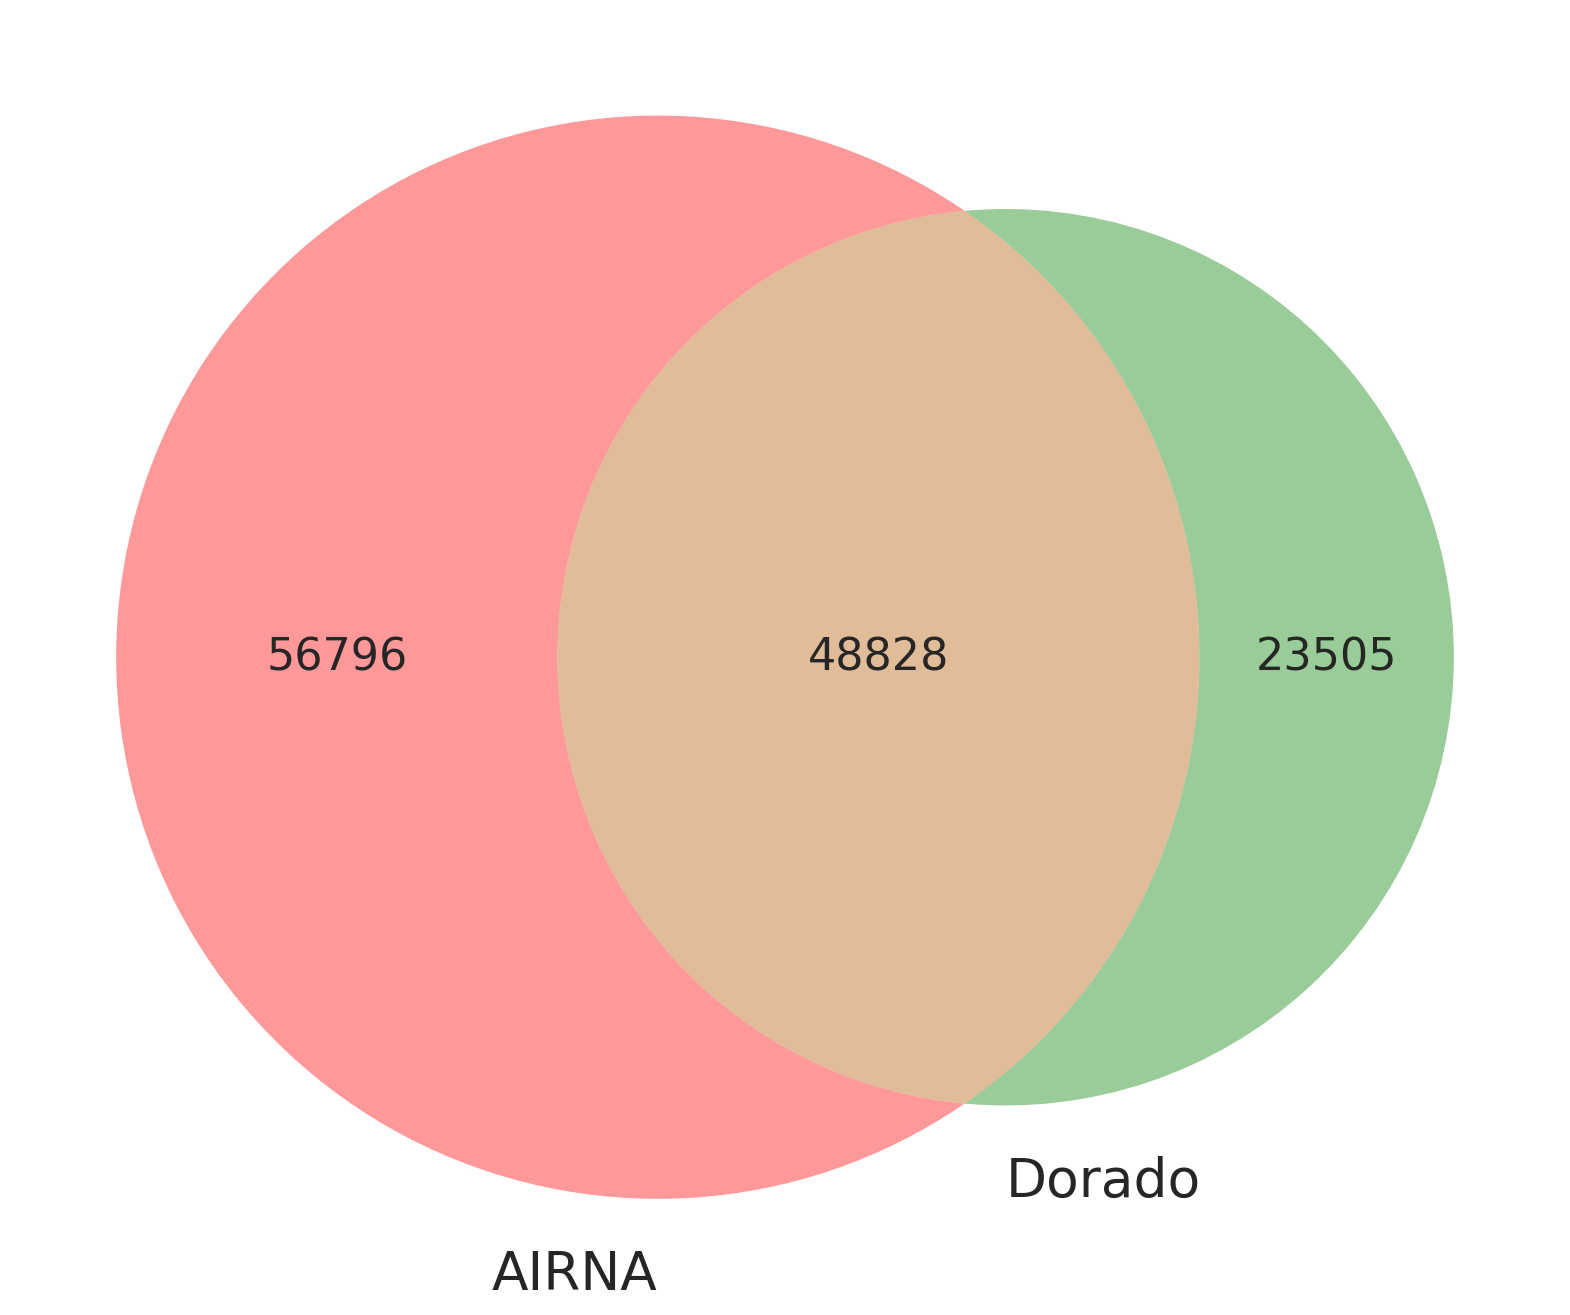

In [207]:
## Plot Venn
import matplotlib_venn as venn
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
## count
venn.venn2([set(airna_arr), set(dorado_arr)], set_labels=("AIRNA", "Dorado"))

plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/venn.pdf", format="pdf")
plt.show()


In [7]:
print(hek_label)

                  id  depth          nmid  pos   5mer  m6A_level  label  \
0       NM_033656:11     10     NM_033656   11  GCACG        0.0      0   
1       NM_033656:16     10     NM_033656   16  GTATG        0.0      0   
2       NM_033656:51     19     NM_033656   51  TGAGA        0.0      0   
3       NM_033656:53     19     NM_033656   53  AGAAG        0.0     -1   
4       NM_033656:54     19     NM_033656   54  GAAGA        0.0      0   
..               ...    ...           ...  ...    ...        ...    ...   
12      NR_003065:61     15     NR_003065   61  TCACC        0.0     -3   
13      NR_003065:68     15     NR_003065   68  TGACT        0.0     -3   
14      NR_003065:72     15     NR_003065   72  TGATG        0.0     -3   
0   NM_001388168:415      6  NM_001388168  415  TTAGG        0.0     -3   
0   NM_001393570:470      6  NM_001393570  470  TCAGG        0.0     -3   

           genome_id  drach  
0   chr21:-:39313620  False  
1   chr21:-:39313615  False  
2   chr21

In [8]:
hek_eval = hek_genomic_df_m6a.merge(hek_label, on="genome_id", how="left")

In [9]:
print(hek_eval)

                genome_id gene_symbol  coding       dom  count_dom  \
0       chr10:+:100364512         SCD    True  0.359959       2942   
1       chr10:+:100364569         SCD    True  0.218364       2995   
2       chr10:+:100381333    OLMALINC   False  0.155556        135   
3       chr10:+:100388236    OLMALINC   False  0.180000        100   
4       chr10:+:100388266    OLMALINC   False  0.339450        109   
...                   ...         ...     ...       ...        ...   
261108    chrX:-:85864614         CHM    True  0.142857         28   
261109    chrX:-:85864679         CHM    True  0.576923         26   
261110    chrX:-:85864679         CHM    True  0.576923         26   
261111    chrX:-:85956342         CHM    True  0.200000         20   
261112    chrX:-:85971260         CHM    True  0.481481         27   

        logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  \
0         -3305.878662        910       3040         1  1.698536   
1         -1664.377441 

In [10]:
print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}))

                   coding  drach
genome_id                       
chr10:+:100364512    True   True
chr10:+:100364569    True   True
chr10:+:100381333   False   True
chr10:+:100388236   False  False
chr10:+:100388266   False   True
...                   ...    ...
chrX:-:85864587      True   True
chrX:-:85864614      True   True
chrX:-:85864679      True   True
chrX:-:85956342      True   True
chrX:-:85971260      True   True

[107081 rows x 2 columns]


In [11]:
## Count DRACH+Coding, DRACH+Noncoding, Non-DRACH+Coding, Non-DRACH+Noncoding
print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/hek_eval["genome_id"].nunique())

print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size())
print(sum(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))

coding  drach
False   False    0.006546
        True     0.050793
True    False    0.084870
        True     0.857790
dtype: float64
coding  drach
False   False      701
        True      5439
True    False     9088
        True     91853
dtype: int64
107081


[90861, 5170, 664, 8929]


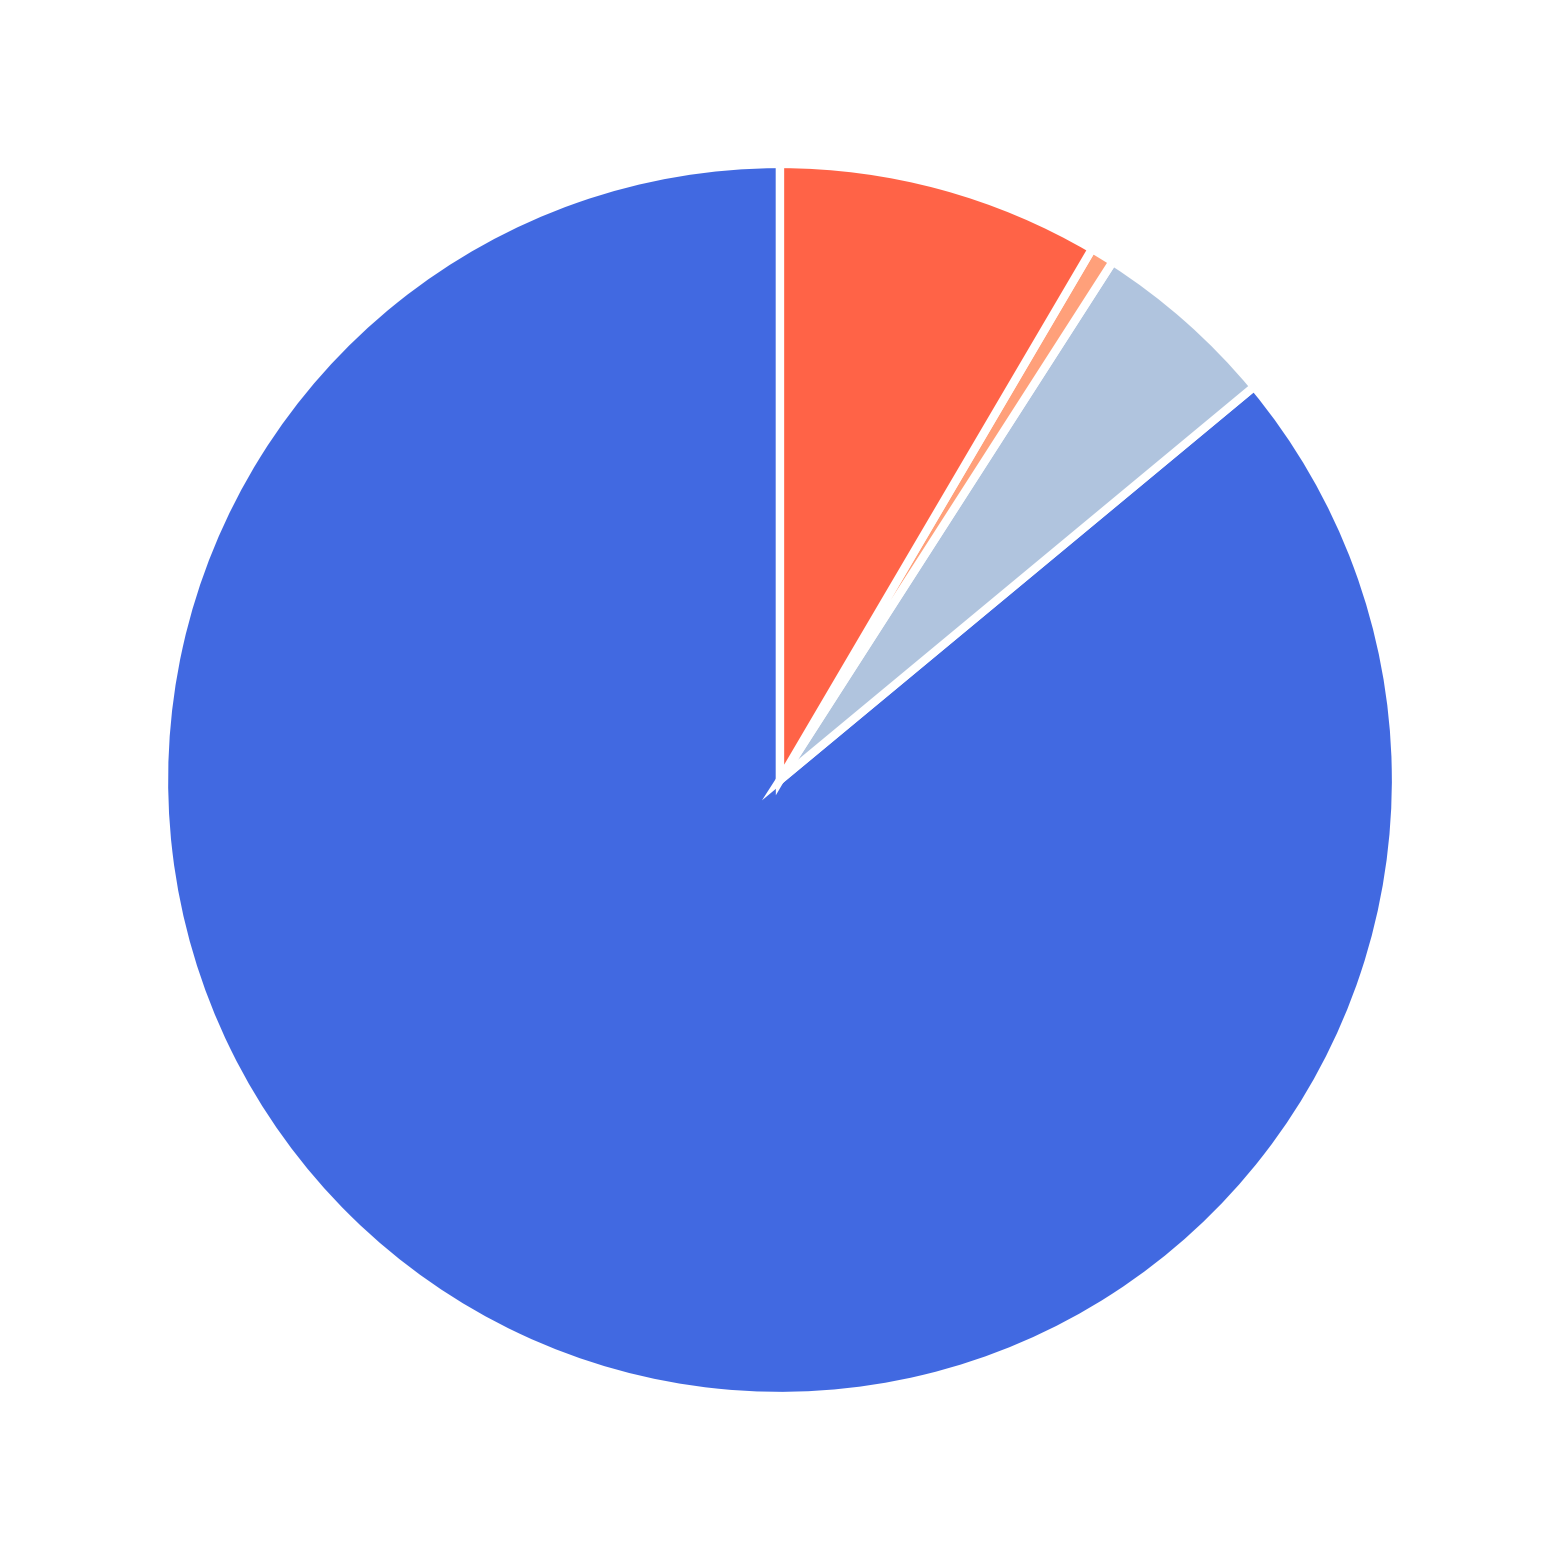

In [23]:
## Plot Pie chart
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [90861, 5170, 664, 8929]
print(y)
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon',  'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_hek.pdf", format="pdf")
plt.show()

In [17]:
hela_label = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/v2Genomic.v2Genomic.GP3.depth5_None.twm6astrict.pkl")
print(hela_label)

               id  depth       nmid  pos   5mer  m6A_level  label  \
0    NM_033656:51      6  NM_033656   51  TGAGA        0.0      0   
1    NM_033656:53      6  NM_033656   53  AGAAG        0.0     -1   
2    NM_033656:54      6  NM_033656   54  GAAGA        0.0      0   
3    NM_033656:56      6  NM_033656   56  AGAGG        0.0      0   
4    NM_033656:61      6  NM_033656   61  GGACG        0.0     -1   
..            ...    ...        ...  ...    ...        ...    ...   
3   NR_120423:104      6  NR_120423  104  GAATC        0.0     -3   
4   NR_120423:108      6  NR_120423  108  CCAGA        0.0     -3   
5   NR_120423:110      6  NR_120423  110  AGAGT        0.0     -3   
6   NR_120423:113      6  NR_120423  113  GTAGT        0.0     -3   
7   NR_120423:127      6  NR_120423  127  CTAGT        0.0     -3   

           genome_id  drach  
0   chr21:-:39313580  False  
1   chr21:-:39313578  False  
2   chr21:-:39313577  False  
3   chr21:-:39313575  False  
4   chr21:-:39313570 

In [18]:
hela_eval = hela_genomic_df_m6a.merge(hela_label, on="genome_id", how="left")
print(hela_eval)

                genome_id gene_symbol  coding       dom  count_dom  \
0       chr10:+:100364512         SCD    True  0.315391       3827   
1       chr10:+:100364569         SCD    True  0.177046       3886   
2       chr10:+:100388266    OLMALINC   False  0.257235        311   
3       chr10:+:100388308    OLMALINC   False  0.392086        278   
4       chr10:+:100548246      HIF1AN    True  0.770115         87   
...                   ...         ...     ...       ...        ...   
226356    chrX:-:85864753         CHM    True  0.131579         38   
226357    chrX:-:85864753         CHM    True  0.131579         38   
226358    chrX:-:85956342         CHM    True  0.222222         27   
226359    chrX:-:85956342         CHM    True  0.222222         27   
226360    chrX:-:85971360         CHM    True  0.238095         21   

        logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  \
0         -3840.107666       1062       3948         1  1.565750   
1         -1921.157959 

In [26]:
print(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size())
print(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/sum(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))
print(sum(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))

coding  drach
False   False      584
        True      4463
True    False     7958
        True     79487
dtype: int64
coding  drach
False   False    0.006314
        True     0.048253
True    False    0.086040
        True     0.859393
dtype: float64
92492


In [127]:
fdr_thr = 0.55

print(np.sum(hela_genomic_df["pm6a"] > fdr_thr))
print(np.sum(hek_genomic_df["pm6a"] > fdr_thr))

hela_genomic_df_m6a_fdr = hela_genomic_df[hela_genomic_df["pm6a"] > fdr_thr].copy()
hek_genomic_df_m6a_fdr= hek_genomic_df[hek_genomic_df["pm6a"] > fdr_thr].copy()
hela_eval_fdr = hela_genomic_df_m6a_fdr.merge(hela_label, on="genome_id", how="left")
hek_eval_fdr = hek_genomic_df_m6a_fdr.merge(hek_label, on="genome_id", how="left")

108303
125916


In [128]:

print(np.sum([hela_genomic_df["pm6a"] > 0.55]))
print(np.sum([hek_genomic_df["pm6a"] > 0.55]))

108303
125916


In [129]:
## Count DRACH+Coding, DRACH+Noncoding, Non-DRACH+Coding, Non-DRACH+Noncoding
print(hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/hek_eval_fdr["genome_id"].nunique())

print(hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["drach"]).size())
print(sum(hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["drach"]).size()))

coding  drach
False   False    0.007735
        True     0.049676
True    False    0.100631
        True     0.841958
dtype: float64
drach
False     13645
True     112271
dtype: int64
125916


In [130]:
## Count DRACH+Coding, DRACH+Noncoding, Non-DRACH+Coding, Non-DRACH+Noncoding
print(hela_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/hela_eval_fdr["genome_id"].nunique())

print(hela_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["drach"]).size())
print(sum(hela_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))

coding  drach
False   False    0.007581
        True     0.047164
True    False    0.101493
        True     0.843762
dtype: float64
drach
False    11813
True     96490
dtype: int64
108303


[79487, 4463, 584, 7958]


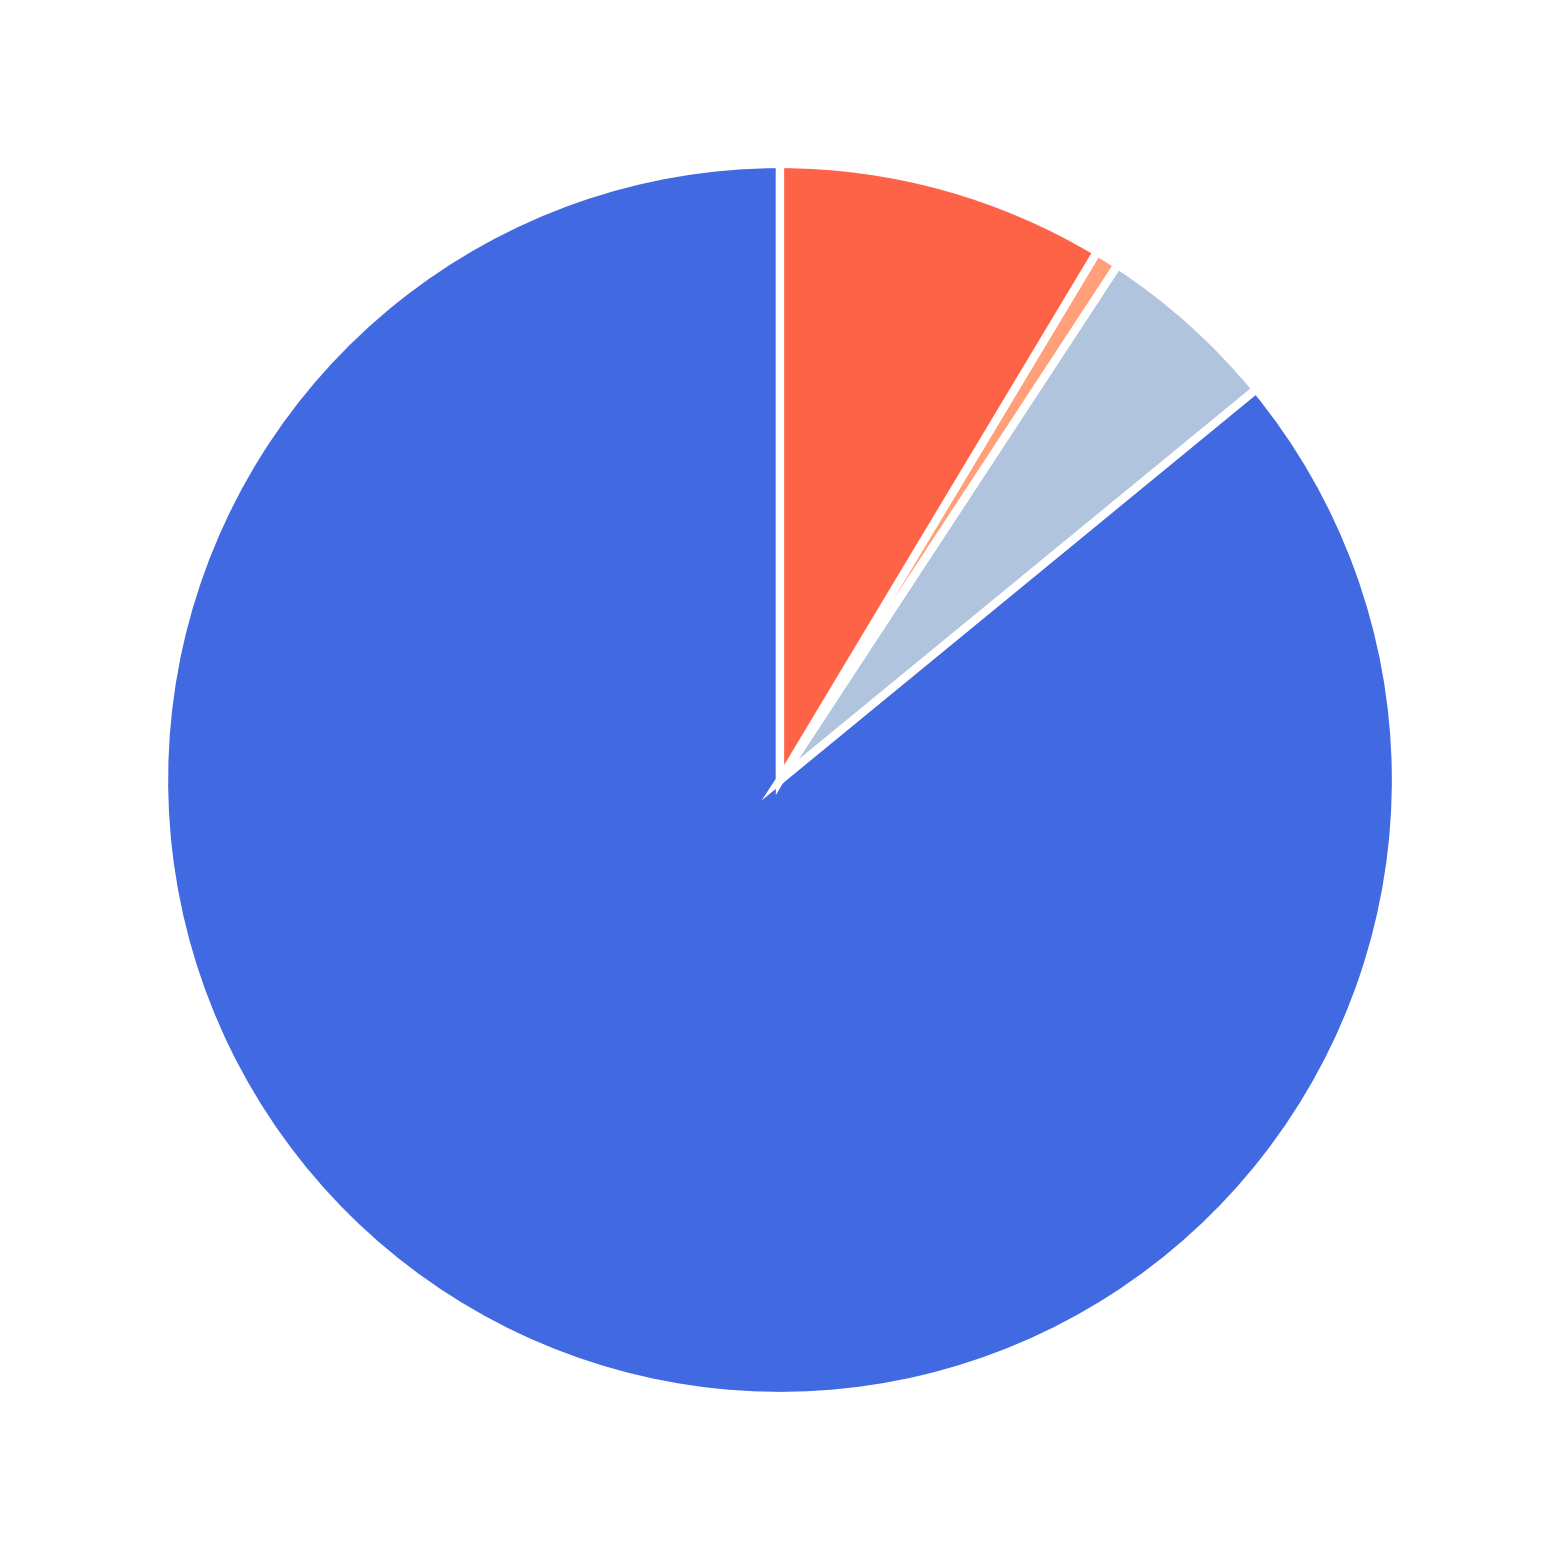

In [30]:
## Plot Pie chart
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [79487, 4463, 584, 7958]
print(y)
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon',  'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_hela.pdf", format="pdf")
plt.show()

In [48]:
def drach_ed(seq):
    ed = 0
    if not seq[0] in ["A", "G", "T", "U"]:
        ed += 1
    if not seq[1] in ["G", "A"]:
        ed += 1
    if not seq[2] == "A":
        ed += 1
    if not seq[3] == "C":
        ed += 1
    if not seq[4] in ["A", "C", "T", "U"]:
        ed += 1
    return ed
        
        


In [895]:
hek_eval["drach_ed"] = hek_eval["5mer"].apply(drach_ed)
print(hek_eval)

                genome_id gene_symbol  coding       dom  count_dom  \
0       chr10:+:100364512         SCD    True  0.359959       2942   
1       chr10:+:100364569         SCD    True  0.218364       2995   
2       chr10:+:100381333    OLMALINC   False  0.155556        135   
3       chr10:+:100388236    OLMALINC   False  0.180000        100   
4       chr10:+:100388266    OLMALINC   False  0.339450        109   
...                   ...         ...     ...       ...        ...   
261108    chrX:-:85864614         CHM    True  0.142857         28   
261109    chrX:-:85864679         CHM    True  0.576923         26   
261110    chrX:-:85864679         CHM    True  0.576923         26   
261111    chrX:-:85956342         CHM    True  0.200000         20   
261112    chrX:-:85971260         CHM    True  0.481481         27   

        logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  \
0         -3305.878662        910       3040         1  1.698536   
1         -1664.377441 

In [46]:
agg_df = hek_eval.groupby("genome_id").agg({"coding": "max", "drach_ed": "max"})
print(agg_df)

KeyError: "Column(s) ['drach_ed'] do not exist"

In [899]:
print(agg_df["drach_ed"].value_counts())

drach_ed
0    97239
1     9558
2      228
3       41
4       15
Name: count, dtype: int64


In [49]:
hek_eval_fdr["drach_ed"] = hek_eval["5mer"].apply(drach_ed)
agg_df = hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach_ed": "max"})
print(agg_df["drach_ed"].value_counts())

drach_ed
0.0    92978
1.0    13090
2.0      304
3.0       50
4.0       24
Name: count, dtype: int64


In [963]:
print(hek_eval[hek_eval["drach_ed"] == 4]["5mer"].value_counts())

5mer
CCATG    15
CCAGG     6
CCAAG     5
CTATG     4
CTAAG     1
CTAGG     1
Name: count, dtype: int64


In [967]:
print(hek_eval[hek_eval["drach_ed"] > 0]["5mer"].value_counts() / len(hek_eval[hek_eval["drach_ed"]  > 0]))
print(hek_eval[hek_eval["drach_ed"] > 0]["5mer"].value_counts())

5mer
GGACG    0.341685
GGATT    0.177739
AGACG    0.073284
GTACT    0.072962
GAACG    0.041056
           ...   
CAAGA    0.000046
GCAGG    0.000046
TGAGG    0.000046
GTATG    0.000046
ACATT    0.000046
Name: count, Length: 153, dtype: float64
5mer
GGACG    7432
GGATT    3866
AGACG    1594
GTACT    1587
GAACG     893
         ... 
CAAGA       1
GCAGG       1
TGAGG       1
GTATG       1
ACATT       1
Name: count, Length: 153, dtype: int64


In [969]:
print(len(hek_eval[hek_eval["drach_ed"] > 0]))
print(len(hek_eval[hek_eval["drach_ed"] > 3]))

21751
32


In [970]:
32/21751

0.0014711967265872833

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


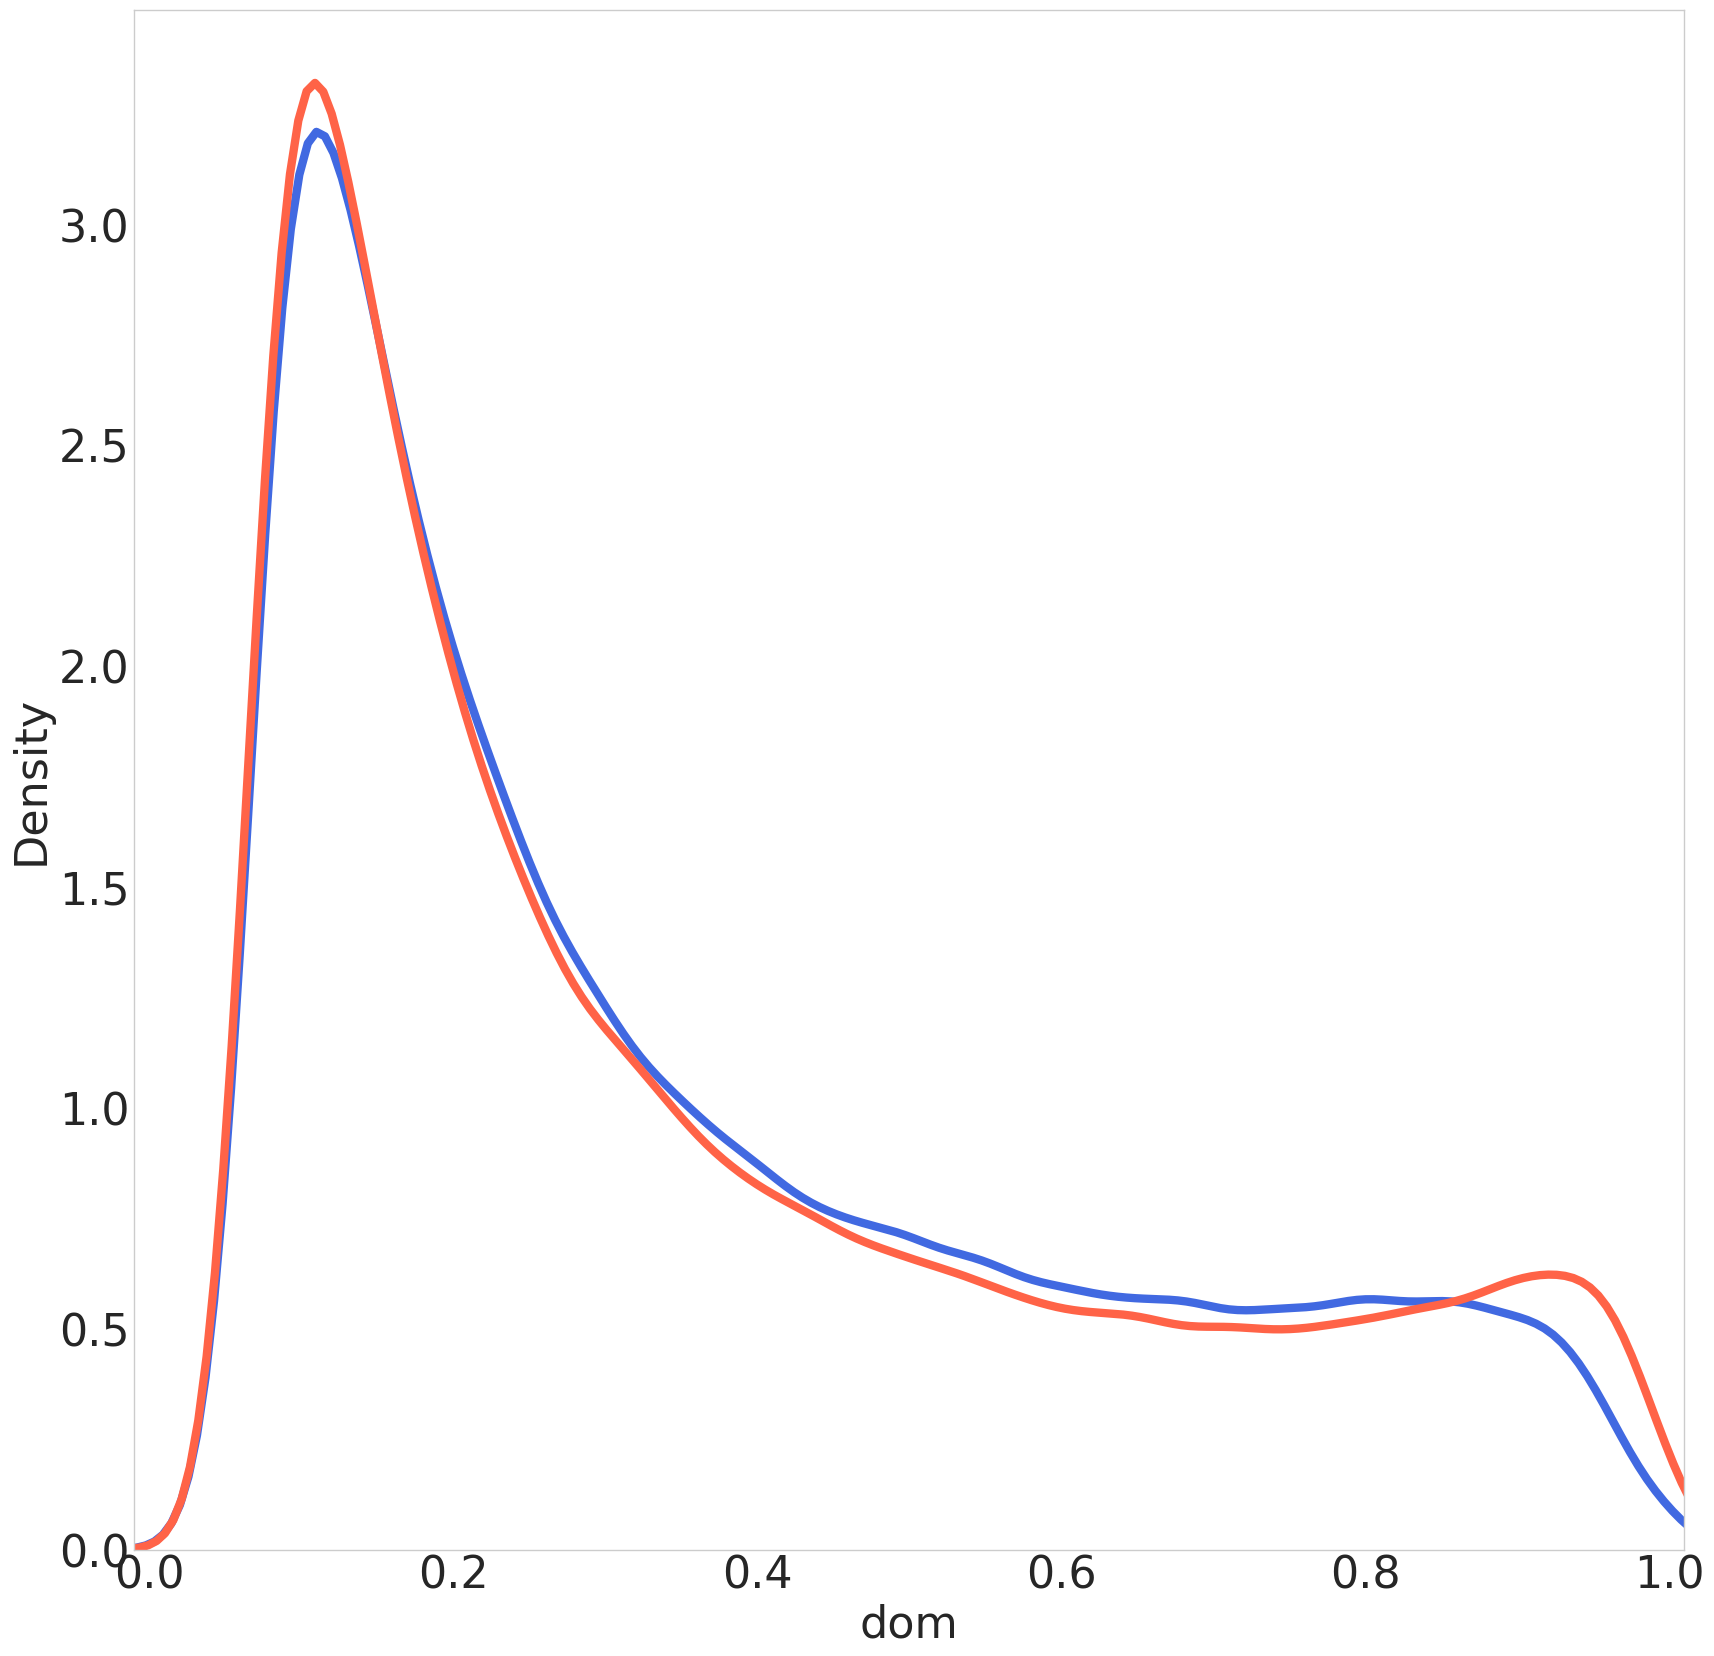

In [50]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval_fdr, x="dom", ax=ax, fill=False, levels=100, color="royalblue", alpha=1.0)
sns.kdeplot(data=hela_eval_fdr, x="dom", ax=ax, fill=False, levels=100, color="tomato",  alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_distribution.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


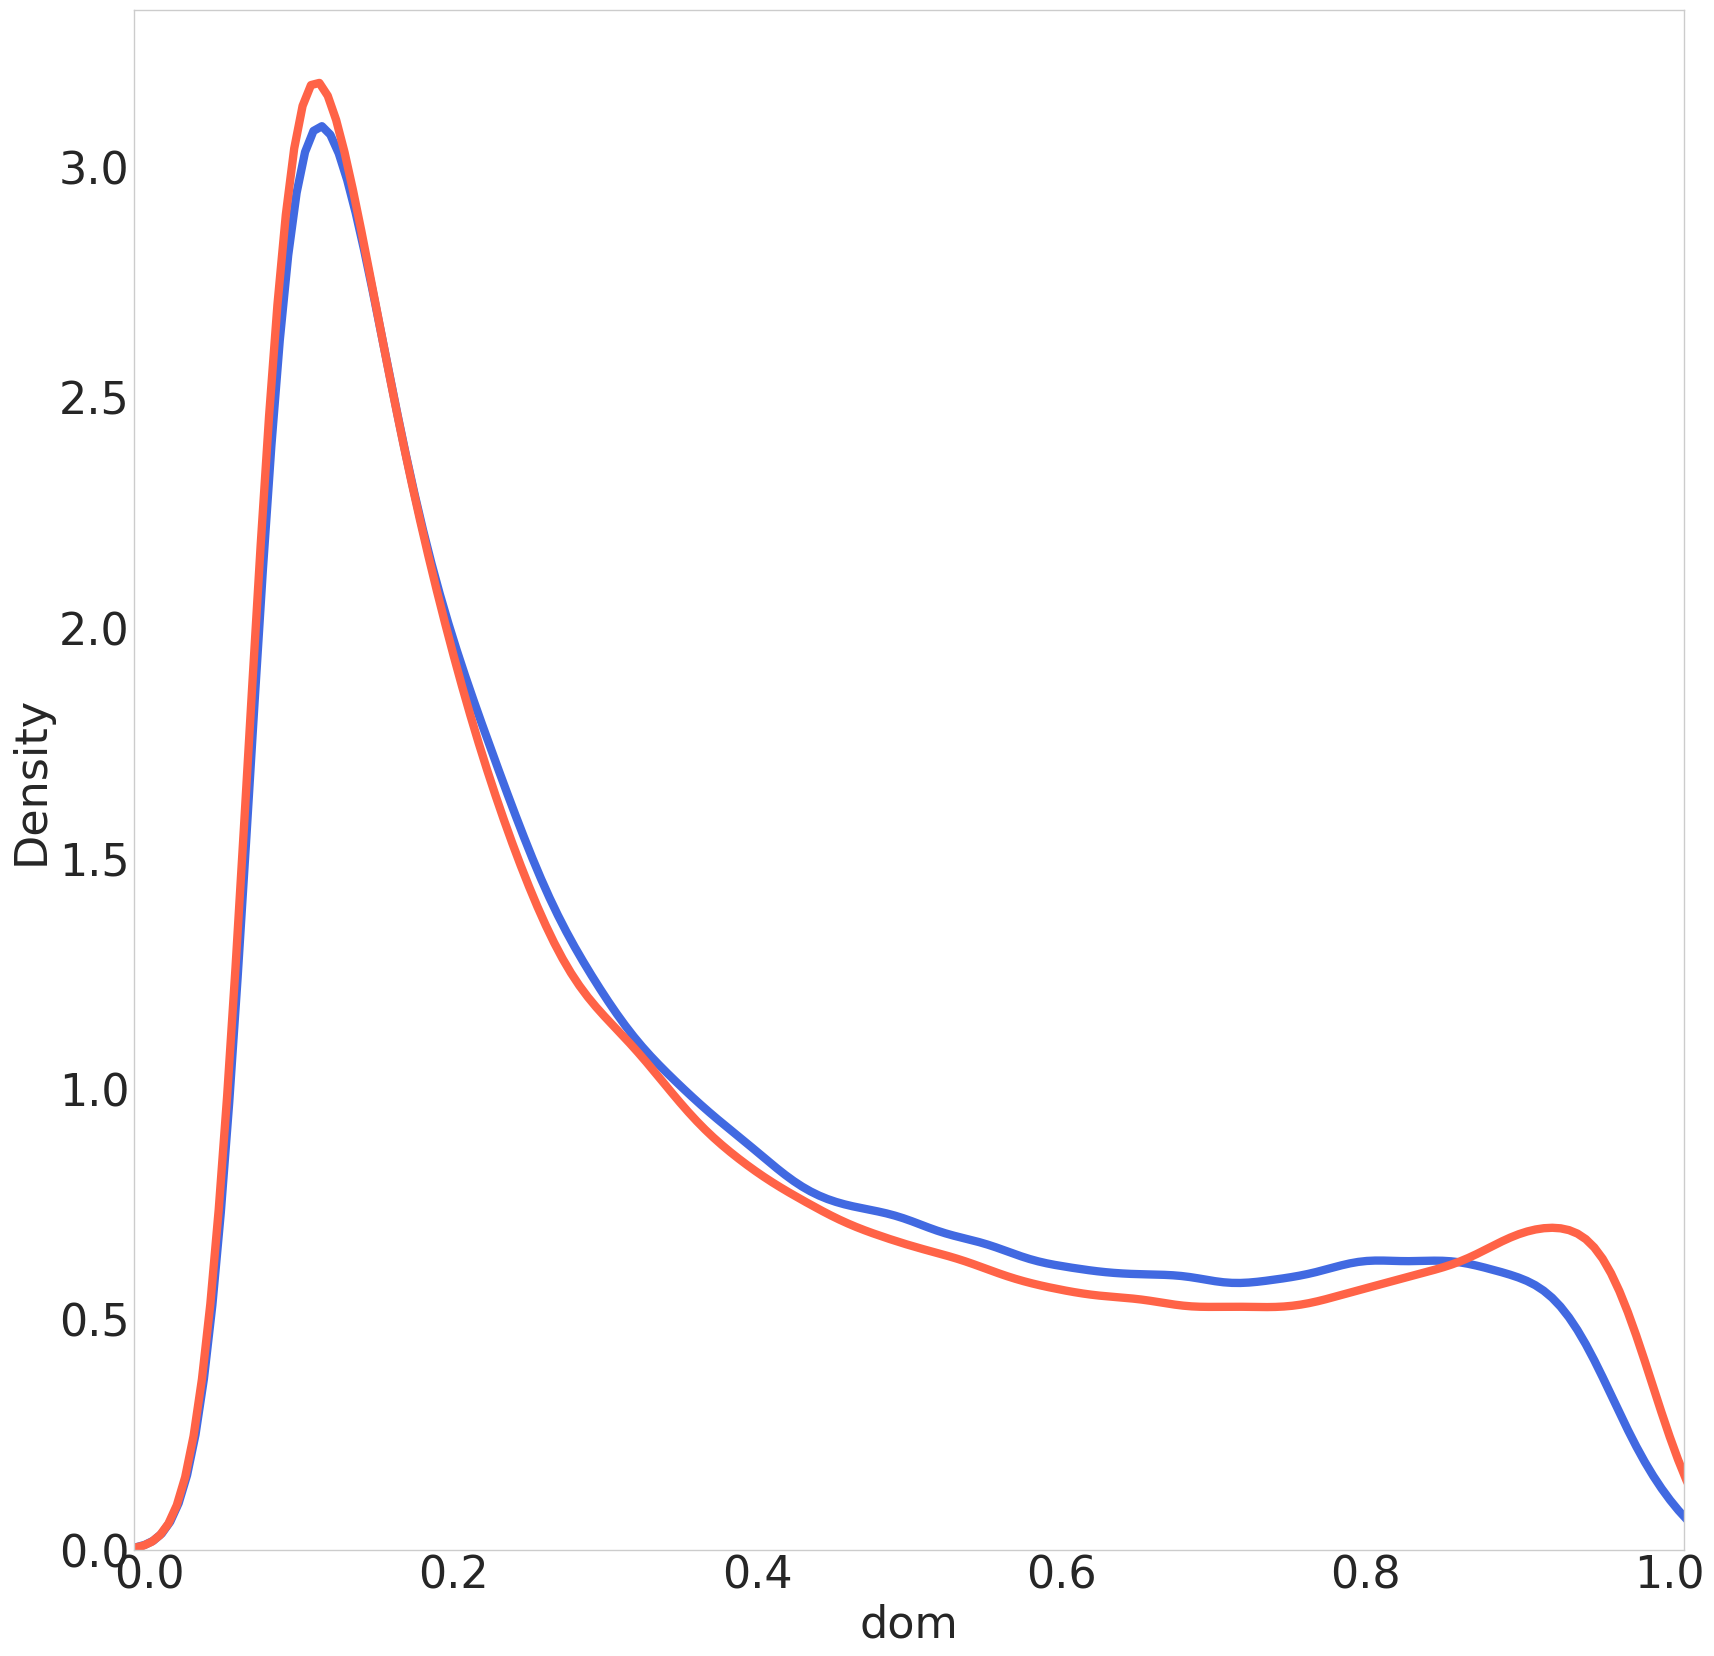

In [53]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval_fdr[hek_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval_fdr[hela_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_drach.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


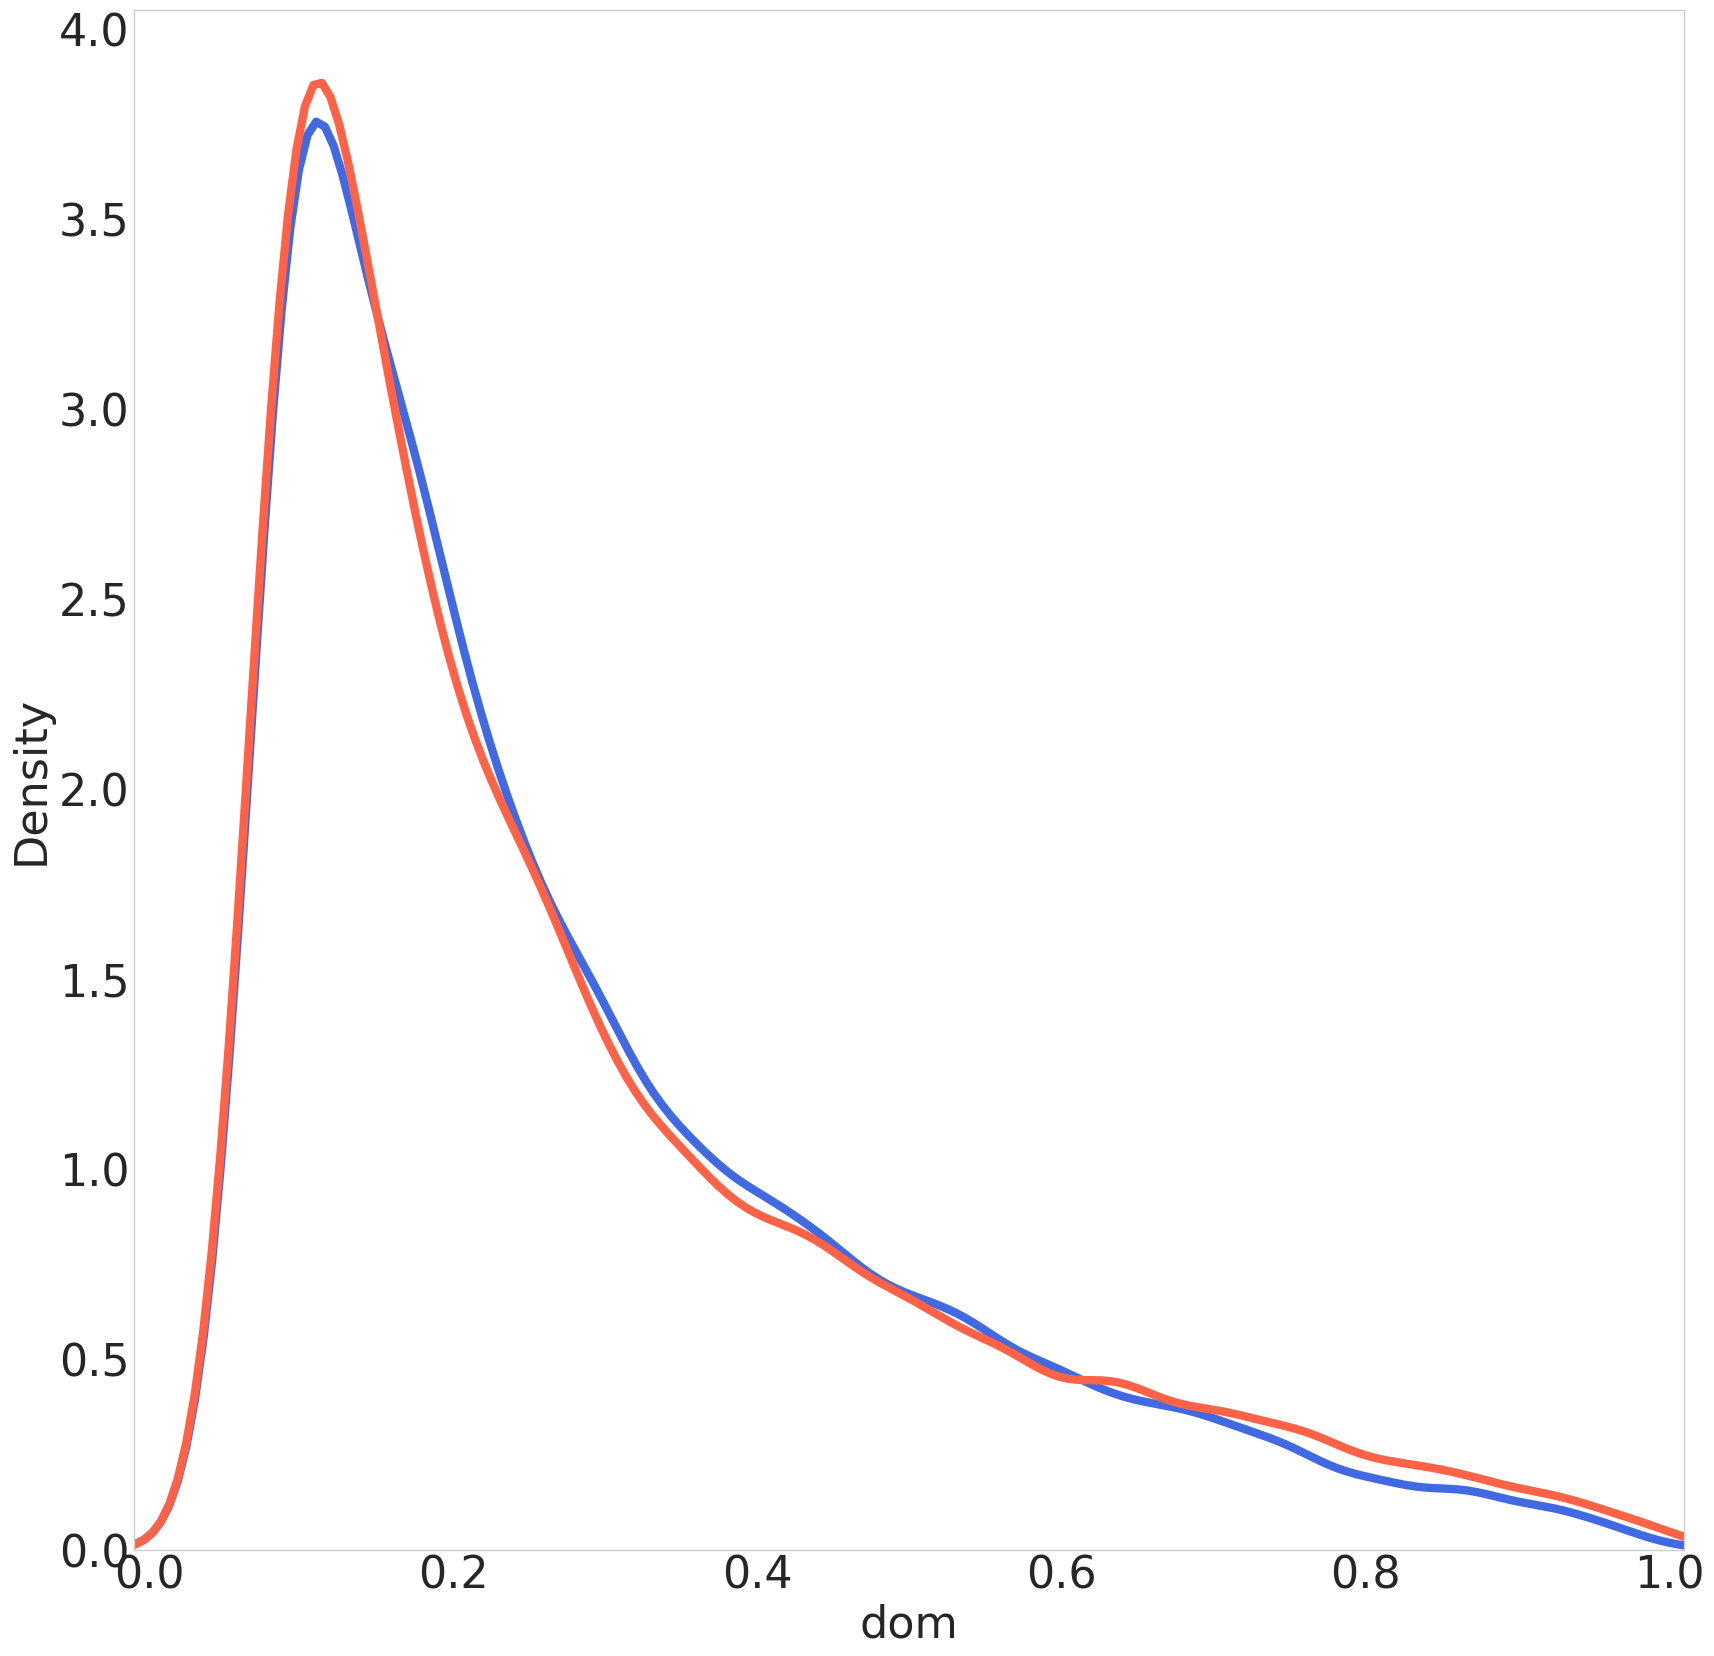

In [54]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval_fdr[~hek_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval_fdr[~hela_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_nondrach.pdf", format="pdf")
plt.show()

In [58]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6A/pileup.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_all"] >= 20]
print(hela_df)

hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_all"] >= 20]
print(hek_df)

                label_id     p_sum  logsum_1_p_pos       dom  count_all  \
0         NM_000016:1000  0.843626             0.0  0.000000        310   
1         NM_000016:1008  1.863539             0.0  0.006452        310   
2         NM_000016:1009  2.171798             0.0  0.003247        311   
3         NM_000016:1010  3.194226             0.0  0.003236        313   
4         NM_000016:1014  4.851071             0.0  0.006557        312   
...                  ...       ...             ...       ...        ...   
26478388   NR_184306:966  0.558527             0.0  0.000000         20   
26478389   NR_184306:967  0.879458             0.0  0.000000         20   
26478391   NR_184306:979  2.395881             0.0  0.058824         20   
26478392    NR_184306:98  5.731736             0.0  0.160000         28   
26478393   NR_184306:984  0.717068             0.0  0.050000         20   

          count_dom  count_pos  
0               308          0  
1               310          0  


In [65]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}
a_count_dict = {x: y.seq.count("A") for x, y in fasta_dict.items()}

In [66]:
## Draw Discrepancy
geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
convert_dict = dict(zip(geneid_table["transcript_id"], geneid_table["gene_id"]))

In [71]:
fdr_threshold = 0.35

hela_df["pm6a"] = calc_pm6a(hela_df)
hek_df["pm6a"] =   calc_pm6a(hek_df)
hela_df["refseq"] = hela_df["label_id"].str.split(":").str[0]
hek_df["refseq"] = hek_df["label_id"].str.split(":").str[0]
hela_df["pos"] = hela_df["label_id"].str.split(":").str[1].astype(int)
hek_df["pos"] = hek_df["label_id"].str.split(":").str[1].astype(int)
hela_df["gene_symbol"] = hela_df["refseq"].map(convert_dict)
hek_df["gene_symbol"] = hek_df["refseq"].map(convert_dict)

In [72]:
hela_df_m6a = hela_df[hela_df["pm6a"] >= fdr_threshold].copy()
hek_df_m6a = hek_df[hek_df["pm6a"] >= fdr_threshold].copy()

In [95]:
hela_arr = hela_genomic_df_m6a_fdr.groupby("gene_symbol").size()
hek_arr = hek_genomic_df_m6a_fdr.groupby("gene_symbol").size()

In [96]:
## Add genes with 0 m6A sites
hela_arr = hela_arr.reindex(hela_genomic_df["gene_symbol"].unique(), fill_value=0)
hek_arr = hek_arr.reindex(hek_genomic_df["gene_symbol"].unique(), fill_value=0)


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


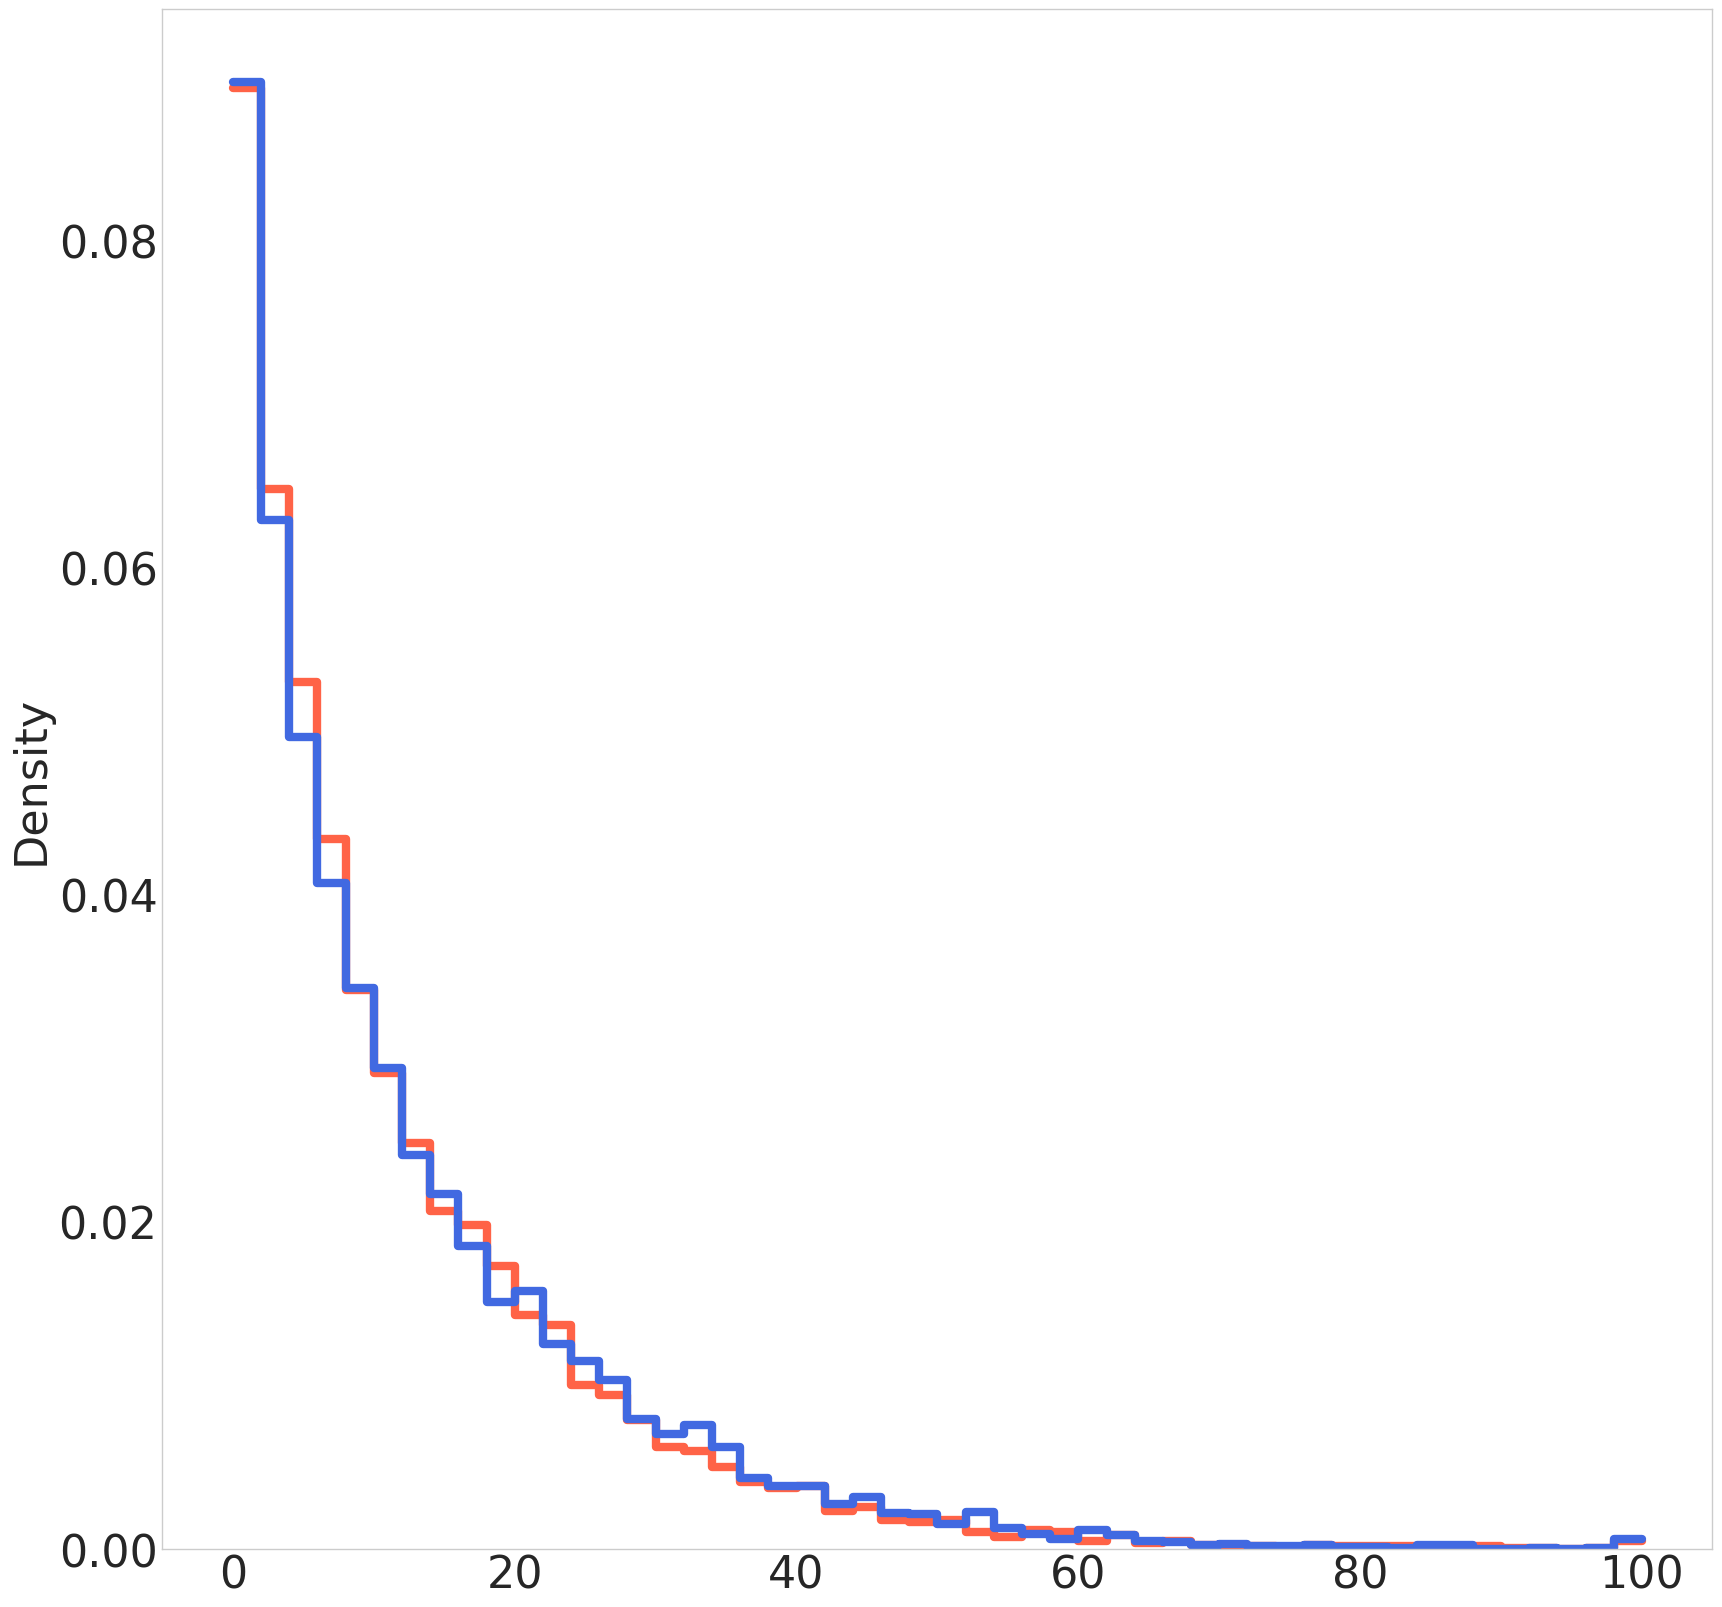

In [98]:
## Plot histogram
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(np.clip(hela_arr, 0, 100), color="tomato", label="HeLa", element="step", ax=ax, fill=False, binwidth=2, stat="density")
sns.histplot(np.clip(hek_arr,  0, 100), color="royalblue", label="HEK293T", element="step", ax=ax, fill=False, binwidth=2, stat="density")
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/density.pdf", format="pdf")
plt.show()

In [106]:
## How many genes have> 30 m6A sites?
print(len(hela_arr[hela_arr > 20])/len(hela_arr))
print(len(hek_arr[hek_arr   > 20])/len(hek_arr))

0.19325309374470248
0.21166831044685533


In [101]:
print(len(hela_arr[hela_arr>100]))

11


In [102]:
print(hek_arr[hek_arr>100])

gene_symbol
MKI67       119
KMT2A       120
AHNAK       141
SACS        127
TBC1D16     101
SPEN        103
DIDO1       123
SON         104
TUG1        102
ALMS1       101
FAT1        140
ANKRD33B    104
KIAA1549    110
EPPK1       106
dtype: int64


In [104]:
print (hek_genomic_df_m6a_fdr[hek_genomic_df_m6a_fdr["gene_symbol"]=="MKI67"])

                genome_id gene_symbol  coding       dom  count_dom  \
385067  chr10:-:128097149       MKI67    True  0.106952        374   
385254  chr10:-:128097812       MKI67    True  0.128743        334   
385271  chr10:-:128097878       MKI67    True  0.386581        313   
385310  chr10:-:128098064       MKI67    True  0.088757        676   
385326  chr10:-:128098161       MKI67    True  0.209440        678   
...                   ...         ...     ...       ...        ...   
388817  chr10:-:128115605       MKI67    True  0.790123         81   
388869  chr10:-:128115724       MKI67    True  0.197531         81   
388903  chr10:-:128115840       MKI67    True  0.746479         71   
388917  chr10:-:128115889       MKI67    True  0.792208         77   
388922  chr10:-:128115898       MKI67    True  0.138889         72   

        logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  
385067     -112.500648         35        388         2  0.535566  
385254     -119.795563   

In [107]:
## How many genes have m6A sites?
print(len(hela_arr[hela_arr > 0])/hela_df["gene_symbol"].nunique())
print(len(hek_arr[hek_arr > 0])/hek_df["gene_symbol"].nunique())

0.9362571022727273
0.9326671425172496


In [108]:
## Average number of m6A sites per gene
print(hela_arr.mean())
print(hek_arr.mean())



11.943804034582133
12.512555951748729


In [109]:
print(hek_arr)
print(hela_arr)

gene_symbol
GTPBP4      12
SCD          9
OLMALINC    10
WNT8B       13
HIF1AN      13
            ..
BRWD3       19
HMGN5        2
RPS6KA6      4
ANOS1       12
CHM         20
Length: 13181, dtype: int64
gene_symbol
GTPBP4      11
SCD          9
OLMALINC     6
HIF1AN       8
SLF2         8
            ..
BRWD3       17
HMGN5        2
POF1B        2
ANOS1       10
CHM         20
Length: 11798, dtype: int64


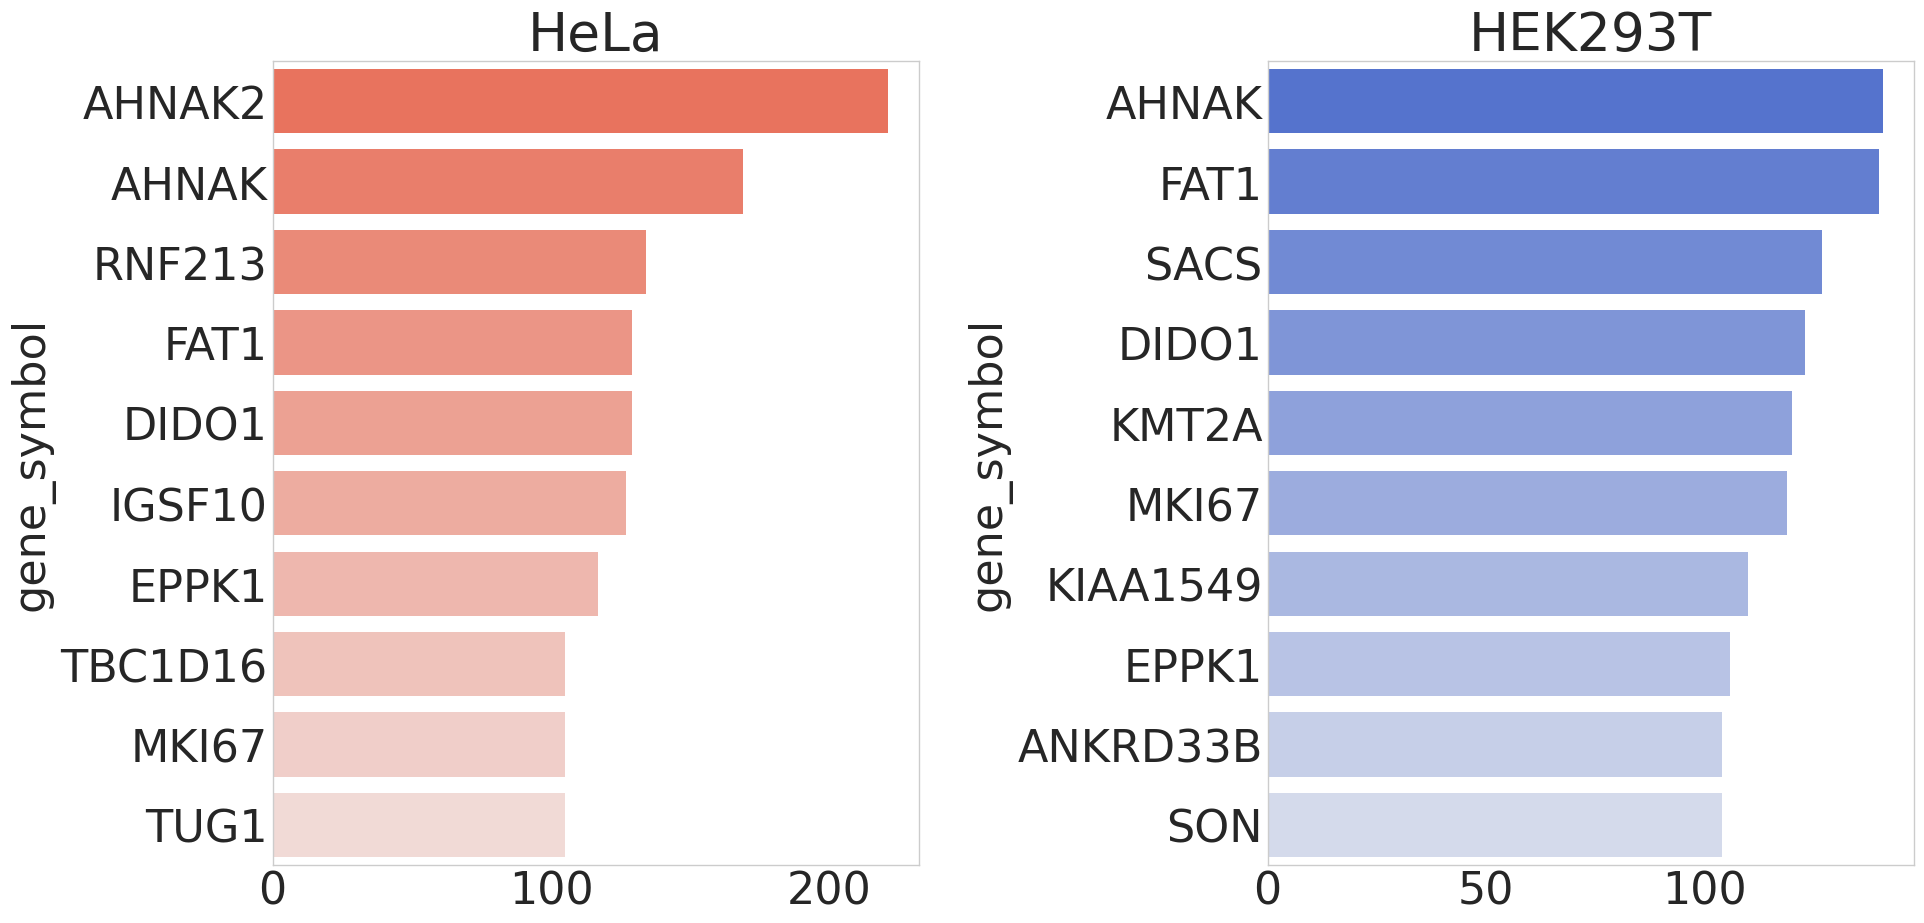

In [110]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
hela_arr = hela_arr.sort_values(ascending=False)
hek_arr = hek_arr.sort_values(ascending=False)
## Vertical bar plot
sns.barplot(x=hela_arr[:10], y=hela_arr[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_arr[:10], y=hek_arr[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [111]:
##print top10 genes

print("\n".join(hela_arr[:10].index))
print("")
print("\n".join(hek_arr[:10].index))

AHNAK2
AHNAK
RNF213
FAT1
DIDO1
IGSF10
EPPK1
TBC1D16
MKI67
TUG1

AHNAK
FAT1
SACS
DIDO1
KMT2A
MKI67
KIAA1549
EPPK1
ANKRD33B
SON


In [112]:
hela_df["pm6a"] = calc_pm6a(hela_df)
hek_df["pm6a"] = calc_pm6a(hek_df)
hela_df["refseq"] = hela_df["label_id"].str.split(":", expand=True)[0]
hek_df["refseq"] = hek_df["label_id"].str.split(":", expand=True)[0]
hela_df["pos"] = hela_df["label_id"].str.split(":", expand=True)[1].astype(int)
hek_df["pos"] = hek_df["label_id"].str.split(":", expand=True)[1].astype(int)

In [ ]:
## Get genes for largest discrepancy

gene_dict = []
for refseq in hela_dict.index:
    if refseq in hek_dict:
        hela_pos = hela_dict[refseq]
        hek_pos = hek_dict[refseq]
        diff = np.setdiff1d(hela_pos, hek_pos)
        if len(diff) > 0:
            gene_dict.append((refseq, len(diff)))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "diff"])

In [ ]:
print(diff_df)

In [ ]:
print(diff_df.sort_values("diff", ascending=False))

In [114]:
print(hela_df[hela_df["refseq"] == "NM_022489"])

                label_id      p_sum  logsum_1_p_pos       dom  count_all  \
20699411    NM_022489:10   4.180888        0.000000  0.040816         51   
20699412  NM_022489:1017  19.446039        0.000000  0.029304        290   
20699413  NM_022489:1029   8.786906       -2.071652  0.014337        290   
20699414  NM_022489:1035   3.258542       -2.332375  0.003484        290   
20699415  NM_022489:1040  12.030365        0.000000  0.014815        282   
...                  ...        ...             ...       ...        ...   
20700709   NM_022489:969  49.773682       -2.314448  0.092920        283   
20700710   NM_022489:971  19.591351        0.000000  0.047794        285   
20700711   NM_022489:972   6.327932        0.000000  0.013986        289   
20700712   NM_022489:977  15.547835       -6.820905  0.040146        285   
20700713   NM_022489:999  13.886819        0.000000  0.028777        288   

          count_dom  count_pos      pm6a     refseq   pos gene_symbol  
20699411       

In [115]:
fdr_threshold = 0.35

hela_m6a_df = hela_df[hela_df["pm6a"] > fdr_threshold]
hek_m6a_df = hek_df[hek_df["pm6a"] > fdr_threshold]

hela_count_df = pd.DataFrame(hela_m6a_df["refseq"].value_counts())
hek_count_df = pd.DataFrame(hek_m6a_df["refseq"].value_counts())

hela_count_df["a_count"] = hela_count_df.index.map(a_count_dict)
hek_count_df["a_count"] = hek_count_df.index.map(a_count_dict)

hela_count_df["density"] = hela_count_df["count"]/hela_count_df["a_count"]
hek_count_df["density"] = hek_count_df["count"]/hek_count_df["a_count"]

hela_count_df["gene_id"] = hela_count_df.index.map(convert_dict)
hek_count_df["gene_id"] = hek_count_df.index.map(convert_dict)

print(hela_count_df)
print(hek_count_df)

              count  a_count   density gene_id
refseq                                        
NM_138420       187     4423  0.042279  AHNAK2
NM_001350929    177     4406  0.040172  AHNAK2
NM_001346446    150     5446  0.027543   AHNAK
NM_001620       147     5444  0.027002   AHNAK
NM_005245       129     4184  0.030832    FAT1
...             ...      ...       ...     ...
NM_000367         1      958  0.001044    TPMT
NM_000224         1      351  0.002849   KRT18
NM_000281         1      189  0.005291   PCBD1
NM_000282         1      727  0.001376    PCCA
NM_000154         1      236  0.004237   GALK1

[20533 rows x 4 columns]
              count  a_count   density gene_id
refseq                                        
NM_005245       139     4184  0.033222    FAT1
NM_002417       127     4175  0.030419   MKI67
NM_001620       114     5444  0.020940   AHNAK
NM_001291411    109     2136  0.051030     SON
NM_031308       106     2710  0.039114   EPPK1
...             ...      ...      

In [117]:
## groupby gene_id, get max density, sort by density
hela_density_df = hela_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)
hek_density_df = hek_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)

print(hela_density_df)
print(hek_density_df)

          density
gene_id          
EXD3     0.132716
ADAT3    0.128713
MC1R     0.101036
MFSD5    0.100000
LRFN4    0.098191
...           ...
ARFGEF3  0.000243
SLFN12L  0.000235
CDKL5    0.000233
HOOK3    0.000230
DYNC2H1  0.000226

[10243 rows x 1 columns]
          density
gene_id          
EXD3     0.138889
ADAT3    0.133663
MFSD5    0.100000
RPRML    0.098592
SDHAF1   0.098039
...           ...
PTPN14   0.000286
PHC3     0.000262
CNTNAP3  0.000248
USF3     0.000248
AAK1     0.000169

[11408 rows x 1 columns]


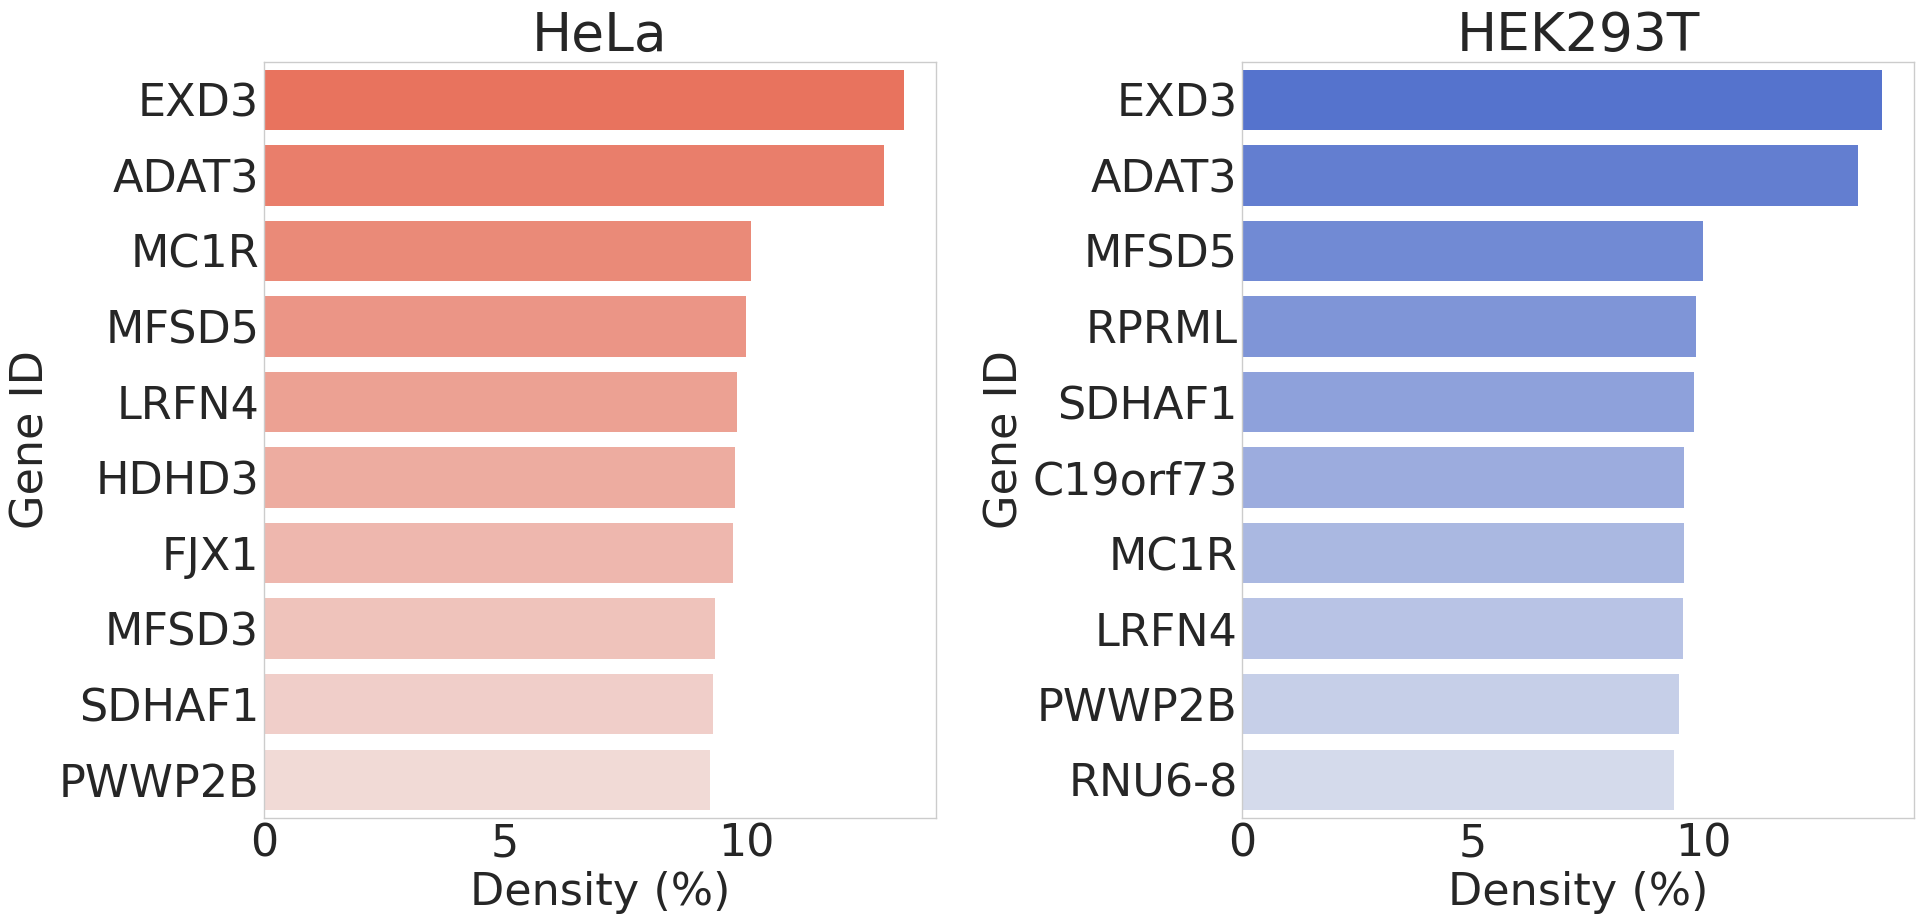

In [118]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
## Vertical bar plot
sns.barplot(x=hela_density_df[:10]["density"]*100, y=hela_density_df[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_density_df[:10]["density"]*100, y=hek_density_df[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
ax[0].set_xlabel("Density (%)")
ax[1].set_xlabel("Density (%)")
ax[0].set_ylabel("Gene ID")
ax[1].set_ylabel("Gene ID")
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [ ]:
hek_count_df = hek_df["refseq"].value_counts()
hela_count_df = hela_df["refseq"].value_counts()
hek_start_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].min())
hela_start_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].min())


In [152]:
## get m6a pos for each refseq
hela_df_m6a = hela_df[hela_df["pm6a"] > threshold].copy()
hek_df_m6a = hek_df[hek_df["pm6a"] > threshold].copy()
hela_dict = hela_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)
hek_dict = hek_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)

In [143]:
print(len(a_count_dict))

87410


In [151]:
hek_end_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].max())
hela_end_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].max())

In [153]:
gene_list = []
for gene_id in tqdm.tqdm(a_count_dict):
    a_count = a_count_dict[gene_id]
    hek_count = hek_count_df.get(gene_id, 0)
    hela_count = hela_count_df.get(gene_id, 0)
    if hek_count >= a_count * 0.75 and hela_count >= a_count * 0.75:
        if np.abs(hela_count - hek_count) < 10:
            if np.abs(hek_start_df.get(gene_id, 0) - hela_start_df.get(gene_id, 0)) < 100:
                if np.abs(hek_end_df.get(gene_id, 0) - hela_end_df.get(gene_id, 0)) < 100:
                    gene_list.append(gene_id)

gene_list = [x for x in a_count_dict if x in hela_dict or x in hek_dict]
gene_len_dict = {x: len(fasta_dict[x]) for x in gene_list}

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87410/87410 [00:02<00:00, 37554.21it/s]


In [154]:
hela_df_ca = hela_df[hela_df["pm6a"] < threshold].copy()
hek_df_ca = hek_df[hek_df["pm6a"] < threshold].copy()

print(len(hela_df_ca)/len(hela_df))
print(len(hek_df_ca)/len(hek_df))

0.9903210943294741
0.9904945792655191


In [155]:

def plot(refseq):    
    hela_refseq_df = hela_df_m6a[hela_df_m6a["refseq"] == refseq]
    hela_pos = hela_refseq_df["pos"].values
    hela_dom = hela_refseq_df["dom"].values
    hek_refseq_df = hek_df_m6a[hek_df_m6a["refseq"] == refseq]
    hek_pos = hek_refseq_df["pos"].values
    hek_dom = hek_refseq_df["dom"].values

    hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])

    hela_pos_bool = np.isin(hela_pos, hek_all_pos)
    hek_pos_bool = np.isin(hek_pos, hela_all_pos)
    
    hela_pos = hela_pos[hela_pos_bool]
    hek_pos = hek_pos[hek_pos_bool]
    hela_dom = hela_dom[hela_pos_bool]
    hek_dom = hek_dom[hek_pos_bool]
    
    print(refseq)
    
    max_pos = gene_len_dict[refseq]
    
    x_min = 0
    x_max = max_pos//100 * 100 + 100
    
    if x_max - x_min > 4000:
        x_grid = 400
    
    elif x_max - x_min > 2000:
        x_grid = 200
    
    else:
        x_grid = 100
    
    fig, ax = plt.subplots(figsize=(20,10))
    
    ax.set_xticks(range(x_min, x_max, x_grid))
    ax.set_xticklabels([str(x) for x in range(x_min, x_max, x_grid)])
    ax.set_xlim(x_min - 10, x_max + 10)
    ax.set_ylim(-1, 1)
    ax.set_yticks(list(np.arange(-1,1.1,0.25)))
    ax.set_yticklabels([f"{x:.2f}" for x in np.arange(-1,1.1,0.25)])
    ax.grid()
    
    barwidth = 0.01 * (x_max - x_min + 20)
    
    ax.bar(hek_pos, hek_dom, label="HEK293T", color="royalblue", width=barwidth)
    ax.bar(hela_pos, -hela_dom, label="HeLa", color="tomato", width=barwidth)
    

    gene_symbol = convert_dict[refseq]

    ax.set_title(f"{gene_symbol}({refseq}) m6A Profile")
    ax.set_xlabel("Position (nt)")
    ax.set_ylabel("Degree of Modification")
    ax.legend() 
    
    ## hline at y=0
    ax.axhline(0, color="black", lw=3)
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/{refseq}.pdf", format="pdf")

    plt.show()


In [160]:
hela_df_ca_groupby = hela_df_ca.groupby("refseq")
hek_df_ca_groupby = hek_df_ca.groupby("refseq")
hela_df_m6a_groupby = hela_df_m6a.groupby("refseq")
hek_df_m6a_groupby = hek_df_m6a.groupby("refseq")

In [161]:
print(hela_df_m6a)

                label_id      p_sum  logsum_1_p_pos       dom  count_all  \
105       NM_000016:1302  83.074715     -204.744171  0.262987        314   
796       NM_000017:1321  23.094213      -70.079582  0.410714         56   
808       NM_000017:1373  36.434132     -107.144432  0.700000         54   
2187      NM_000021:1584  81.548790     -281.050110  0.920455         90   
2208      NM_000021:1655  44.096100     -109.763779  0.494253         92   
...                  ...        ...             ...       ...        ...   
26475241  NR_184208:2650  61.044514     -208.400848  0.458015        133   
26475261  NR_184208:2729  42.515171     -123.167091  0.302326        135   
26475280  NR_184208:2808  41.628223     -131.709732  0.309524        132   
26478350    NR_184306:77   6.222351      -22.432709  0.214286         28   
26478381    NR_184306:93  18.177622      -54.774170  0.666667         29   

          count_dom  count_pos      pm6a     refseq   pos gene_symbol  
105            

In [162]:

gene_dict = []
for refseq in tqdm.tqdm(gene_list):
    try:
        hela_pos = hela_dict[refseq]
        hela_dom = hela_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hela_pos = []
        hela_dom = []
    try:
        hek_pos = hek_dict[refseq]
        hek_dom = hek_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hek_pos = []
        hek_dom = []
        
    try:
        hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hela_ca_pos = []
    try:
        hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hek_ca_pos = []
    
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])
    
    

    hela_dom_dict = dict(zip(hela_pos, hela_dom))
    hek_dom_dict = dict(zip(hek_pos, hek_dom))

    unique = 0
    
    hela_valid_pos = []
    hek_valid_pos = []
    
    hela_arr = []
    hek_arr = []
    
    for pos in np.union1d(hela_pos, hek_pos):
        if pos in hela_all_pos and pos in hek_all_pos:
            if pos in hela_pos:
                hela_valid_pos.append(pos)
            if pos in hek_pos:
                hek_valid_pos.append(pos)
            hela_dom = hela_dom_dict.get(pos, 0)
            hek_dom = hek_dom_dict.get(pos, 0)
            hela_arr.append(hela_dom)
            hek_arr.append(hek_dom)
            if hela_dom*hek_dom == 0:
                unique += 1
                    
    if len(hela_arr) > 0 or len(hek_arr) > 0:
        
        hela_arr = np.array(hela_arr)
        hek_arr = np.array(hek_arr)
        hela_valid_pos = np.array(hela_valid_pos)
        hek_valid_pos = np.array(hek_valid_pos)
    
        i = np.intersect1d(hela_valid_pos, hek_valid_pos)
        u = np.union1d(hela_valid_pos, hek_valid_pos)
        
        cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
        if np.isnan(cosine_sim):
            cosine_sim = 0
        cross_entropy = -np.sum(hela_arr*np.log(hek_arr+1e-30) + (1-hela_arr)*np.log(1-hek_arr+1e-30))/len(hela_arr)
        iou = len(i)/len(u)
        
        hela_size = len(hela_valid_pos)
        hek_size = len(hek_valid_pos)
        
        l1 = np.mean(np.abs(hela_arr-hek_arr))
        l2 = np.mean((hela_arr-hek_arr)**2) ** 0.5
        
        gene_dict.append((refseq, cosine_sim, cross_entropy, hela_size, hek_size, iou, unique, l1, l2))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "cosine_sim", "cross_entropy", "hela_size", "hek_size", "iou", "unique", "l1", "l2"])

print(diff_df)

  0%|                                                                                                                                                          | 1/23499 [00:07<48:15:25,  7.39s/it]/tmp/ipykernel_175708/971843873.py:64: RuntimeWarning: invalid value encountered in scalar divide
  cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23499/23499 [00:35<00:00, 669.13it/s]

          refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
0      NM_000016    1.000000       0.580291          1         1  1.000000   
1      NM_000017    0.976950       0.486861          2         3  0.666667   
2      NM_000021    0.986966       2.591599         20        16  0.800000   
3      NM_000027    1.000000       0.601162          1         1  1.000000   
4      NM_000028    1.000000       0.609066          1         1  1.000000   
...          ...         ...            ...        ...       ...       ...   
15916  NR_183625    0.993684       0.483107          3         3  1.000000   
15917  NR_183758    0.985076       0.569233          2         2  1.000000   
15918  NR_183824    0.980185       0.462120          7         9  0.777778   
15919  NR_184202    0.549092       4.434755          2         4  0.200000   
15920  NR_184306    0.998859       0.581957          2         2  1.000000   

       unique        l1        l2  
0           0  0.038652  0.

In [163]:
diff_df = diff_df.sort_values("l2", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 3) & (diff_df["l2"] > 0.4) & (diff_df["refseq"].str.startswith("NM"))]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
2120   NM_001161546    0.000000       1.209203          0        16  0.000000   
6810   NM_001394497    0.000000       1.041383          0         4  0.000000   
9659      NM_012292    0.000000      40.209066          6         0  0.000000   
3617   NM_001282334    0.000000      40.464515          6         0  0.000000   
67        NM_000229    0.564954      32.232502          3         1  0.333333   
9716      NM_012446    0.528962      23.435425          2         3  0.666667   
8260      NM_004289    0.359830       0.945761          1        19  0.052632   
3190   NM_001258328    0.000000      36.389068          4         0  0.000000   
9181      NM_006453    0.182908       2.132946          2         8  0.111111   
6731   NM_001388389    0.746334      21.813116          3         2  0.666667   
4902   NM_001321232    0.000000      34.764441          6         0  0.000000   
6733   NM_001388394    0.737

In [169]:
weak_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) < 5]
moderate_mod = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 5)&(diff_df[["hela_size","hek_size"]].max(axis=1) <= 20)]
strong_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) > 20]
print(np.sum(weak_mod["unique"] > 0) , len(weak_mod))
print(np.sum(moderate_mod["unique"] > 0) , len(moderate_mod))
print(np.sum(strong_mod["unique"] > 0) , len(strong_mod))

4207 7961
5829 6816
1125 1144


In [ ]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

In [165]:
print(diff_df)
print(sum(diff_df["unique"] > 0))

             refseq  cosine_sim  cross_entropy  hela_size  hek_size   iou  \
15551     NR_134525    0.000000       1.945910          0         1  0.00   
15700     NR_146152    0.405664      18.210616          2         3  0.25   
2745   NM_001201483    0.000000      56.254774          1         0  0.00   
15363     NR_104049    0.000000      55.262042          1         0  0.00   
13740     NM_152421    0.000000       1.606493          0         1  0.00   
...             ...         ...            ...        ...       ...   ...   
2233   NM_001166135    1.000000       0.617242          1         1  1.00   
11538     NM_019103    1.000000       0.585953          1         1  1.00   
15402     NR_109927    1.000000       0.646091          1         1  1.00   
2264   NM_001167607    1.000000       0.540204          1         1  1.00   
1213   NM_001098801    1.000000       0.693147          1         1  1.00   

       unique            l1            l2  
15551       1  8.571429e-01  8.

In [150]:
plot("NM_001282617")

NameError: name 'plot' is not defined

In [ ]:
diff_df["gene_symbol"] = diff_df["refseq"].map(convert_dict)
print(diff_df)

In [ ]:
diff_df_unique = diff_df[diff_df["unique"] > 0]["gene_symbol"].unique()
print(len(diff_df_unique))

In [911]:
glori_df["seq"] = glori_df.apply(lambda x: "".join(fasta_dict[x["NMID"]][x["transcript_coordinate"]-2:x["transcript_coordinate"]+3]), axis=1)
print(glori_df)

          Chr Strand      Sites  m6A_level_rep1  m6A_level_rep2 chrstrand  \
0        chr9      +  134440485         0.69333         0.77922     chr9+   
1        chr9      +  134440485         0.69333         0.77922     chr9+   
2        chr9      +  134440485         0.69333         0.77922     chr9+   
3        chr9      -  137300014         0.78736         0.82895     chr9-   
4        chr9      -  137300274         0.62796         0.66242     chr9-   
...       ...    ...        ...             ...             ...       ...   
495172  chr17      +   48051150         0.91228         0.89783    chr17+   
495173  chr17      +   48051150         0.91228         0.89783    chr17+   
495174  chr17      +   48051197         0.34035         0.36547    chr17+   
495175  chr17      +   48051197         0.34035         0.36547    chr17+   
495176  chr17      +   48051197         0.34035         0.36547    chr17+   

                NMID  transcript_coordinate    seq  
0          NM_002957  

In [171]:
hela_temp = hela_df[["label_id","pm6a","dom","count_all"]].copy()
hela_temp.rename(columns={"pm6a": "pm6a_hela", "dom": "dom_hela", "count_all": "count_hela"}, inplace=True)
hek_temp = hek_df[["label_id","pm6a","dom","count_all"]].copy()
hek_temp.rename(columns={"pm6a": "pm6a_hek", "dom": "dom_hek", "count_all": "count_hek"}, inplace=True)
joint_df = hela_temp.merge(hek_temp, on="label_id", how="inner")

print(joint_df)


                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
0         NM_000016:1000   0.000000  0.000000         310  0.000000  0.000000   
1         NM_000016:1008  -0.000000  0.006452         310  0.000000  0.000000   
2         NM_000016:1009  -0.000000  0.003247         311 -0.000000  0.003891   
3         NM_000016:1010  -0.000000  0.003236         313 -0.000000  0.011583   
4         NM_000016:1014  -0.000000  0.006557         312  0.000000  0.000000   
...                  ...        ...       ...         ...       ...       ...   
11904485    NR_184306:85   0.000000  0.000000          27  0.000000  0.000000   
11904486    NR_184306:87   0.000000  0.000000          29  0.092186  0.061224   
11904487    NR_184306:88   0.000000  0.000000          29 -0.000000  0.039216   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   
11904489    NR_184306:98  -0.000000  0.160000          28  0.000000  0.000000   

          count_hek  
0    

In [172]:
joint_df["pm6a_max"] = joint_df[["pm6a_hela", "pm6a_hek"]].max(axis=1)
print(joint_df[joint_df["pm6a_max"] > threshold])

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
105       NM_000016:1302   1.072059  0.262987         314  0.913509  0.224335   
784       NM_000017:1321   1.873339  0.410714          56  2.021584  0.492063   
796       NM_000017:1373   2.422191  0.700000          54  2.437110  0.632000   
872       NM_000017:1829   0.529033  0.129630          55  0.756829  0.138462   
2169      NM_000021:1584   3.262655  0.920455          90  3.293502  0.992908   
...                  ...        ...       ...         ...       ...       ...   
11903849  NR_184202:2382   0.141574  0.142857          35  0.721337  0.277778   
11903917  NR_184202:2552   0.335639  0.178571          34  0.888797  0.368421   
11903992  NR_184202:2708   0.759827  0.523810          35  0.968670  0.533333   
11904484    NR_184306:77   1.382304  0.214286          28  1.229243  0.260870   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   

          count_hek  pm6a_m

In [173]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df.reset_index(inplace=True)
print(label_df)

             index        label_id  depth  label  dom_label   5mer  drach
0                0    NM_000084:34      7      0        0.0  GCAGA  False
1                1    NM_000084:36      7      0        0.0  AGAGA  False
2                2    NM_000084:38      7      0        0.0  AGAAT  False
3                3    NM_000084:39      7      0        0.0  GAATG  False
4                4    NM_000084:43      7      0        0.0  GCAGC  False
...            ...             ...    ...    ...        ...    ...    ...
30960573  30960573  NR_183446:1338     51     -3        0.0  AGAAG  False
30960574  30960574  NR_183446:1339     51     -3        0.0  GAAGC  False
30960575  30960575  NR_183446:1347     51     -3        0.0  TCATT  False
30960576  30960576  NR_183446:1350     51     -3        0.0  TTAGC  False
30960577  30960577  NR_183446:1353     51     -3        0.0  GCAGG  False

[30960578 rows x 7 columns]


In [174]:
joint_df = joint_df.merge(label_df, on="label_id", how="inner")

In [175]:
print(joint_df)

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
0         NM_000016:1000   0.000000  0.000000         310  0.000000  0.000000   
1         NM_000016:1008  -0.000000  0.006452         310  0.000000  0.000000   
2         NM_000016:1009  -0.000000  0.003247         311 -0.000000  0.003891   
3         NM_000016:1010  -0.000000  0.003236         313 -0.000000  0.011583   
4         NM_000016:1014  -0.000000  0.006557         312  0.000000  0.000000   
...                  ...        ...       ...         ...       ...       ...   
11904485    NR_184306:85   0.000000  0.000000          27  0.000000  0.000000   
11904486    NR_184306:87   0.000000  0.000000          29  0.092186  0.061224   
11904487    NR_184306:88   0.000000  0.000000          29 -0.000000  0.039216   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   
11904489    NR_184306:98  -0.000000  0.160000          28  0.000000  0.000000   

          count_hek  pm6a_m

In [176]:
print(joint_df[joint_df["pm6a_max"] > threshold])

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
105       NM_000016:1302   1.072059  0.262987         314  0.913509  0.224335   
784       NM_000017:1321   1.873339  0.410714          56  2.021584  0.492063   
796       NM_000017:1373   2.422191  0.700000          54  2.437110  0.632000   
872       NM_000017:1829   0.529033  0.129630          55  0.756829  0.138462   
2169      NM_000021:1584   3.262655  0.920455          90  3.293502  0.992908   
...                  ...        ...       ...         ...       ...       ...   
11903849  NR_184202:2382   0.141574  0.142857          35  0.721337  0.277778   
11903917  NR_184202:2552   0.335639  0.178571          34  0.888797  0.368421   
11903992  NR_184202:2708   0.759827  0.523810          35  0.968670  0.533333   
11904484    NR_184306:77   1.382304  0.214286          28  1.229243  0.260870   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   

          count_hek  pm6a_m

In [177]:
print(joint_df[joint_df["pm6a_max"] > threshold]["drach"].value_counts())

drach
True     111393
False     11733
Name: count, dtype: int64


In [178]:
joint_m6a_df = joint_df[(joint_df["pm6a_max"] > threshold)]

In [179]:
joint_m6a_df["pm6a_min"] = joint_m6a_df[["pm6a_hela", "pm6a_hek"]].min(axis=1)
print(joint_m6a_df[joint_m6a_df["pm6a_min"] < threshold / 2])

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
2624      NM_000021:4498   0.747271  0.095238          21  0.000000  0.000000   
6420       NM_000033:270   0.309682  0.127517         160  1.560611  0.352941   
6507      NM_000033:3130   0.938932  0.151724         297 -0.000000  0.018868   
6551        NM_000033:33   0.116624  0.068966         151  1.052101  0.218750   
19318     NM_000093:1394   0.294042  0.051852         286  1.031963  0.185185   
...                  ...        ...       ...         ...       ...       ...   
11901098  NR_182757:2528   0.208836  0.071429          29  0.721238  0.166667   
11901174  NR_183259:1100   1.144818  0.192308          26  0.170865  0.040000   
11902896  NR_183824:1319   0.251407  0.128205          52  0.976195  0.283582   
11903849  NR_184202:2382   0.141574  0.142857          35  0.721337  0.277778   
11903917  NR_184202:2552   0.335639  0.178571          34  0.888797  0.368421   

          count_hek  pm6a_m

/tmp/ipykernel_175708/2385075935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joint_m6a_df["pm6a_min"] = joint_m6a_df[["pm6a_hela", "pm6a_hek"]].min(axis=1)


In [180]:
print(joint_m6a_df[joint_m6a_df["pm6a_min"] < threshold]["drach"].value_counts())

drach
True     23132
False     4649
Name: count, dtype: int64


In [181]:
print(joint_m6a_df[joint_m6a_df["pm6a_min"] >= threshold]["drach"].value_counts())

drach
True     88261
False     7084
Name: count, dtype: int64


In [878]:
print(hela_m6a_df)

                label_id      p_sum  logsum_1_p_pos       dom  count_all  \
105       NM_000016:1302  83.074715     -204.744171  0.262987        314   
796       NM_000017:1321  23.094213      -70.079582  0.410714         56   
808       NM_000017:1373  36.434132     -107.144432  0.700000         54   
2187      NM_000021:1584  81.548790     -281.050110  0.920455         90   
2208      NM_000021:1655  44.096100     -109.763779  0.494253         92   
...                  ...        ...             ...       ...        ...   
26475241  NR_184208:2650  61.044514     -208.400848  0.458015        133   
26475261  NR_184208:2729  42.515171     -123.167091  0.302326        135   
26475280  NR_184208:2808  41.628223     -131.709732  0.309524        132   
26478350    NR_184306:77   6.222351      -22.432709  0.214286         28   
26478381    NR_184306:93  18.177622      -54.774170  0.666667         29   

          count_dom  count_pos      pm6a     refseq   pos  
105             308        

In [879]:
print(hek_m6a_df)

                label_id       p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
105       NM_000016:1302   59.435646     -0.070924     -143.232574         53   
796       NM_000017:1321   63.604126     -0.024067     -186.799698         56   
808       NM_000017:1373   81.015984     -0.050018     -246.843155         73   
884       NM_000017:1829   18.840462     -0.010739      -54.854488         17   
2187      NM_000021:1584  140.329544     -0.049864     -470.108673        135   
...                  ...         ...           ...             ...        ...   
30885992  NR_184072:1390   11.149197     -0.009197      -21.414343          7   
30886070   NR_184072:502   18.020029     -0.004983      -38.183949         11   
30886114   NR_184072:695    7.077993     -0.000780      -14.006842          4   
30894404    NR_184306:77   13.487498     -0.001975      -36.067211         10   
30894435    NR_184306:93   32.341377     -0.011076      -78.301079         23   

          logsum_p_neg  log

In [781]:

gene_dict = []
for refseq in tqdm.tqdm(gene_list):
    try:
        hela_pos = hela_dict[refseq]
        hela_dom = hela_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hela_pos = []
        hela_dom = []
    try:
        hek_pos = hek_dict[refseq]
        hek_dom = hek_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hek_pos = []
        hek_dom = []

    try:
        hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hela_ca_pos = []
    try:
        hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hek_ca_pos = []

    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])



    hela_dom_dict = dict(zip(hela_pos, hela_dom))
    hek_dom_dict = dict(zip(hek_pos, hek_dom))

    unique = 0

    hela_valid_pos = []
    hek_valid_pos = []

    hela_arr = []
    hek_arr = []

    for pos in np.intersect1d(hela_pos, hek_pos):
        if pos in hela_pos:
            hela_valid_pos.append(pos)
        if pos in hek_pos:
            hek_valid_pos.append(pos)
        hela_dom = hela_dom_dict.get(pos, 0)
        hek_dom = hek_dom_dict.get(pos, 0)
        hela_arr.append(hela_dom)
        hek_arr.append(hek_dom)
        if hela_dom*hek_dom == 0:
            unique += 1

    if len(hela_arr) > 0 or len(hek_arr) > 0:

        hela_arr = np.array(hela_arr)
        hek_arr = np.array(hek_arr)
        hela_valid_pos = np.array(hela_valid_pos)
        hek_valid_pos = np.array(hek_valid_pos)

        i = np.intersect1d(hela_valid_pos, hek_valid_pos)
        u = np.union1d(hela_valid_pos, hek_valid_pos)

        cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
        if np.isnan(cosine_sim):
            cosine_sim = 0
        cross_entropy = -np.sum(hela_arr*np.log(hek_arr+1e-30) + (1-hela_arr)*np.log(1-hek_arr+1e-30))/len(hela_arr)
        iou = len(i)/len(u)

        hela_size = len(hela_valid_pos)
        hek_size = len(hek_valid_pos)

        l1 = np.mean(np.abs(hela_arr-hek_arr))
        l2 = np.mean((hela_arr-hek_arr)**2) ** 0.5

        gene_dict.append((refseq, cosine_sim, cross_entropy, hela_size, hek_size, iou, unique, l1, l2))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "cosine_sim", "cross_entropy", "hela_size", "hek_size", "iou", "unique", "l1", "l2"])

print(diff_df)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23106/23106 [00:27<00:00, 844.02it/s]

          refseq  cosine_sim  cross_entropy  hela_size  hek_size  iou  unique  \
0      NM_000016    1.000000       0.580291          1         1  1.0       0   
1      NM_000017    0.991440       0.655773          2         2  1.0       0   
2      NM_000021    0.995532       0.546238         16        16  1.0       0   
3      NM_000027    1.000000       0.601162          1         1  1.0       0   
4      NM_000028    1.000000       0.609066          1         1  1.0       0   
...          ...         ...            ...        ...       ...  ...     ...   
14279  NR_183514    0.982779       2.412777         10        10  1.0       0   
14280  NR_183625    0.993684       0.483107          3         3  1.0       0   
14281  NR_183758    0.985076       0.569233          2         2  1.0       0   
14282  NR_183824    0.997845       0.519713          7         7  1.0       0   
14283  NR_184306    0.998859       0.581957          2         2  1.0       0   

             l1        l2  

In [785]:
diff_df = diff_df.sort_values("cosine_sim", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 2) & (diff_df["cosine_sim"] < 0.85)]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size  iou  \
9050      NM_014947    0.849497       0.845918          2         2  1.0   
10191     NM_018482    0.835141       0.672802          6         6  1.0   
3781   NM_001303405    0.823118       0.687709          3         3  1.0   
2773   NM_001256462    0.773149       0.813538          2         2  1.0   
10566     NM_021067    0.750368       0.660033          3         3  1.0   

       unique        l1        l2  
9050        0  0.265315  0.309130  
10191       0  0.161093  0.209501  
3781        0  0.145188  0.187626  
2773        0  0.245142  0.270651  
10566       0  0.188937  0.212403  


In [ ]:



for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

In [806]:
sema_dict = {x for x in convert_dict if "SEMA3" in convert_dict[x] and x.startswith("NM")}
print(sema_dict)

{'NM_012431', 'NM_006080', 'NM_001290063', 'NM_001290062', 'NM_001350120', 'NM_001384902', 'NM_001350121', 'NM_001290061', 'NM_001005914', 'NM_004186', 'NM_020163', 'NM_001290060', 'NM_001384903', 'NM_152754', 'NM_001318798', 'NM_001384901', 'NM_001318800', 'NM_001384900', 'NM_004636', 'NM_001178129', 'NM_006379'}


NM_004186


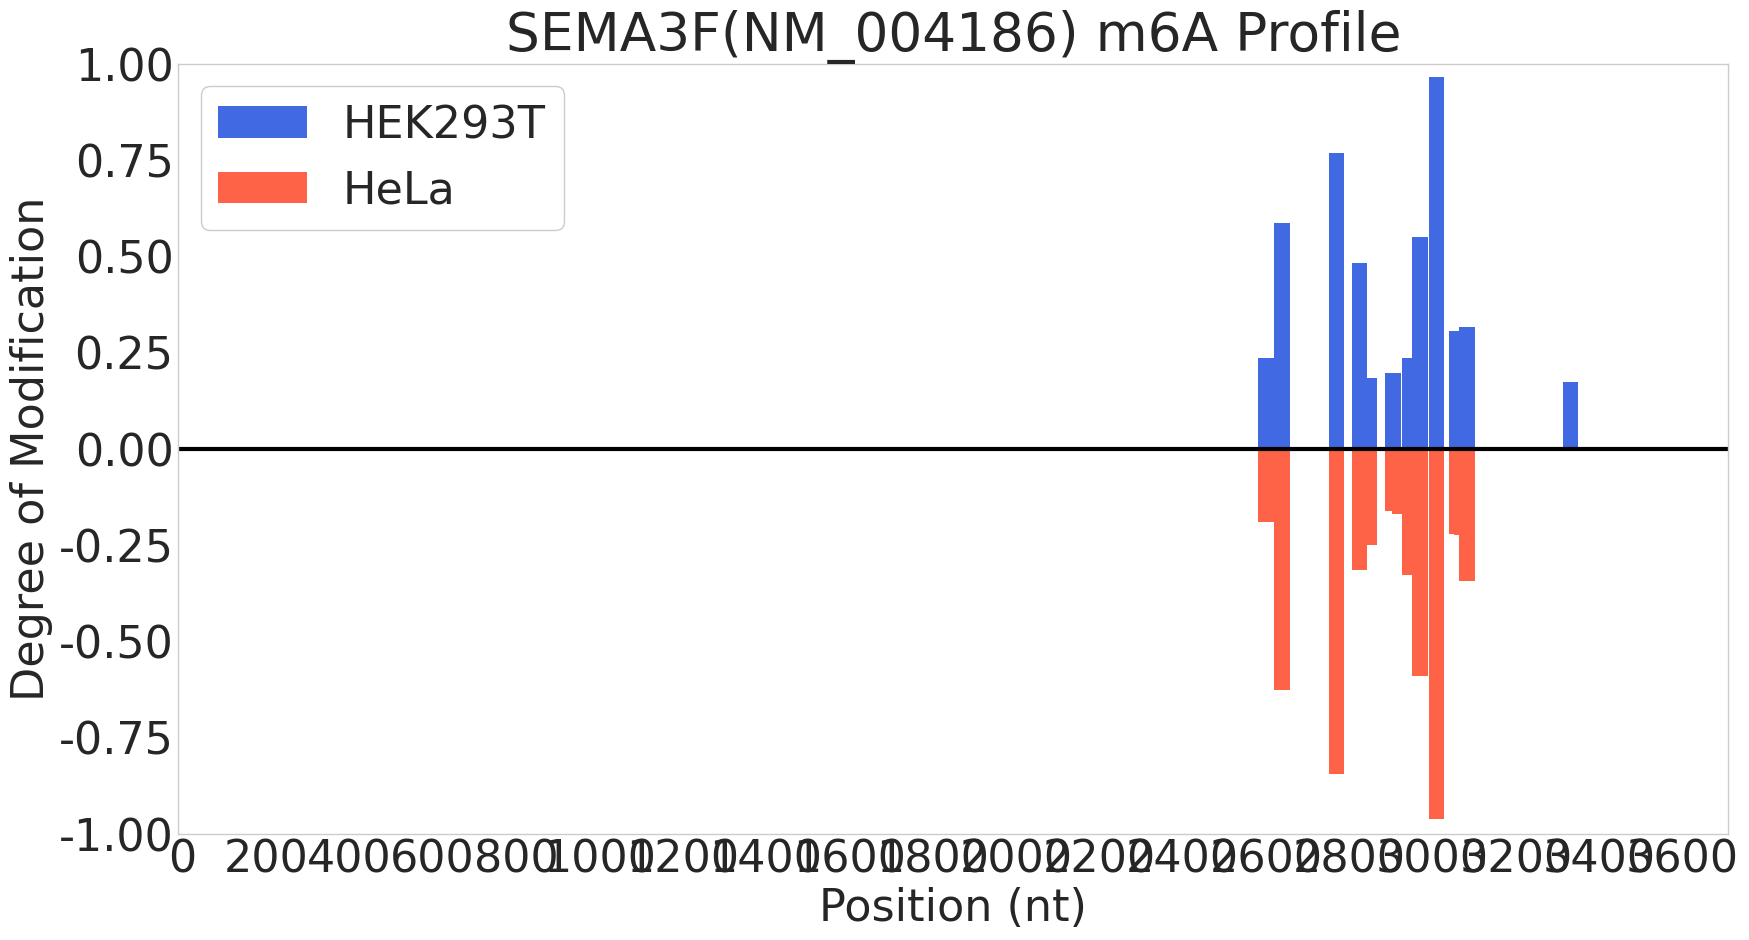

In [809]:
plot("NM_004186")

In [55]:
plot("NM_001069")

NameError: name 'plot' is not defined

NM_004761


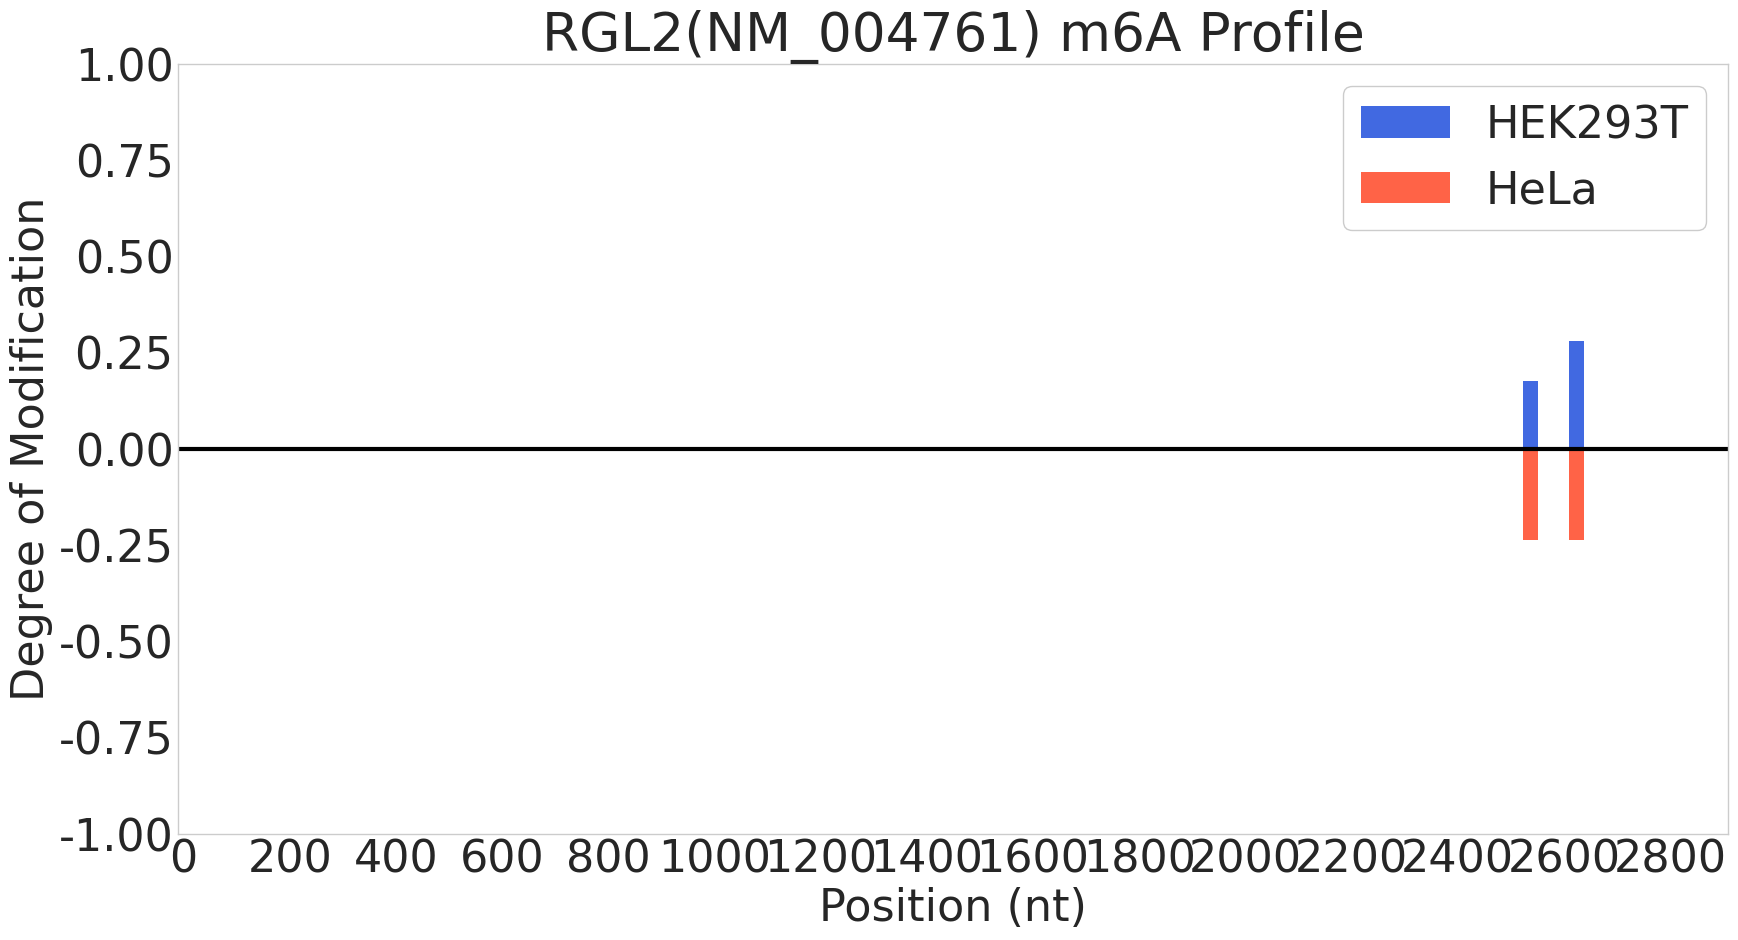

In [812]:
plot("NM_004761")

In [904]:
## Count DRACH and non-DRACH in GLORI

glori_df = "/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/glori_reformatted.tsv"
glori_df = pd.read_csv(glori_df, sep="\t")


In [905]:
print(glori_df)

          Chr Strand      Sites  m6A_level_rep1  m6A_level_rep2 chrstrand  \
0        chr9      +  134440485         0.69333         0.77922     chr9+   
1        chr9      +  134440485         0.69333         0.77922     chr9+   
2        chr9      +  134440485         0.69333         0.77922     chr9+   
3        chr9      -  137300014         0.78736         0.82895     chr9-   
4        chr9      -  137300274         0.62796         0.66242     chr9-   
...       ...    ...        ...             ...             ...       ...   
495172  chr17      +   48051150         0.91228         0.89783    chr17+   
495173  chr17      +   48051150         0.91228         0.89783    chr17+   
495174  chr17      +   48051197         0.34035         0.36547    chr17+   
495175  chr17      +   48051197         0.34035         0.36547    chr17+   
495176  chr17      +   48051197         0.34035         0.36547    chr17+   

                NMID  transcript_coordinate  
0          NM_002957         

In [912]:
import re

def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

In [913]:

glori_df["drach"] = glori_df["seq"].apply(is_drach)

In [919]:
glori_df_drach = glori_df.groupby(["chrstrand","Sites"]).agg({"drach": "max"})
print(glori_df_drach)

                    drach
chrstrand Sites          
chr1+     827634    False
          841506     True
          841558     True
          841599     True
          841882    False
...                   ...
chrY+     12839999  False
          12918210   True
          25482976   True
          25483299   True
          25483361   True

[130890 rows x 1 columns]


In [920]:
print(glori_df_drach["drach"].value_counts())

drach
True     112787
False     18103
Name: count, dtype: int64


In [921]:
print(18103/(18103+112787))

0.13830697532279013


In [923]:

x = 28038 + 19760 + 16267 + 15841 + 15596 + 12374 + 8253  + 6291  + 6079  + 6034  + 3699  + 3648  + 2893  + 2739 
print(x)

147512


In [925]:
print(28038/170240)

0.1646968984962406


In [933]:
genomic_fasta = "/extdata3/baeklab/Hyeonseo/m6A/res/ref/GCF_000001405.40_GRCh38.p14_genomic.fna"
genomic_fasta = SeqIO.to_dict(SeqIO.parse(genomic_fasta, "fasta"))

In [957]:
glori_df = "/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/glori_m6a.tsv"
glori_df = pd.read_csv(glori_df, sep="\t")
print(glori_df)

          Chr     Sites Strand          Gene  AGCov_rep1  AGCov_rep2  \
0       chr10     47499      -         TUBB8          76          65   
1       chr10   3835789      +          ELSE          33          31   
2       chr10   3899385      +          ELSE          60          57   
3       chr10   5357066      +          ELSE          65          53   
4       chr10   7596572      +          ELSE          28          30   
...       ...       ...    ...           ...         ...         ...   
170235   chrY  25307890      +       RPL41P6          27          33   
170236   chrY  25307971      +       RPL41P6          87          92   
170237   chrY  25308031      +       RPL41P6          36          38   
170238   chrY  25393262      -  LINC00265-3P          29          19   
170239   chrY  25393626      -  LINC00265-3P         213         211   

        m6A_level_rep1  m6A_level_rep2 Cluster_info  
0              0.30263         0.24615  Non-cluster  
1              0.69697     

In [950]:

def ncid_to_chr(ncid):
    ncid_int = int(ncid.split(".")[0][3:])
    if ncid_int <= 22:
        chr = f"chr{ncid_int}"
    elif ncid_int == 23:
        chr = "chrX"
    elif ncid_int == 24:
        chr = "chrY"
    elif ncid_int == 12920:
        chr = "chrM"
    else:
        chr = None
    return chr


In [952]:
genomic_fasta_dict = {}
for ncid in genomic_fasta:
    chr = ncid_to_chr(ncid)
    if chr:
        if chr not in genomic_fasta_dict:
            genomic_fasta_dict[chr] = genomic_fasta[ncid]
        else:
            raise ValueError(f"Duplicate chromosome {chr}")

print(genomic_fasta_dict.keys())

dict_keys(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY', 'chrM'])


In [954]:

def revcomp_DNA(seq):
    seq = seq.upper()
    basemap = dict(zip("ATUCG", "TAAGC"))
    if any([i not in basemap for i in seq]):
        raise None
    return "".join([basemap[i] for i in seq[::-1]])


In [958]:
glori_df["seq"] = glori_df.apply(lambda x: "".join(genomic_fasta_dict[x["Chr"]][x["Sites"]-3:x["Sites"]+2]), axis=1)
glori_df["seq"] = glori_df.apply(lambda x: revcomp_DNA(x["seq"]) if x["Strand"] == "-" else x["seq"].upper(), axis=1)
print(glori_df)

          Chr     Sites Strand          Gene  AGCov_rep1  AGCov_rep2  \
0       chr10     47499      -         TUBB8          76          65   
1       chr10   3835789      +          ELSE          33          31   
2       chr10   3899385      +          ELSE          60          57   
3       chr10   5357066      +          ELSE          65          53   
4       chr10   7596572      +          ELSE          28          30   
...       ...       ...    ...           ...         ...         ...   
170235   chrY  25307890      +       RPL41P6          27          33   
170236   chrY  25307971      +       RPL41P6          87          92   
170237   chrY  25308031      +       RPL41P6          36          38   
170238   chrY  25393262      -  LINC00265-3P          29          19   
170239   chrY  25393626      -  LINC00265-3P         213         211   

        m6A_level_rep1  m6A_level_rep2 Cluster_info    seq  
0              0.30263         0.24615  Non-cluster  GAACA  
1            

In [959]:

glori_df = glori_df[glori_df["seq"].notnull()]
print(glori_df)

          Chr     Sites Strand          Gene  AGCov_rep1  AGCov_rep2  \
0       chr10     47499      -         TUBB8          76          65   
1       chr10   3835789      +          ELSE          33          31   
2       chr10   3899385      +          ELSE          60          57   
3       chr10   5357066      +          ELSE          65          53   
4       chr10   7596572      +          ELSE          28          30   
...       ...       ...    ...           ...         ...         ...   
170235   chrY  25307890      +       RPL41P6          27          33   
170236   chrY  25307971      +       RPL41P6          87          92   
170237   chrY  25308031      +       RPL41P6          36          38   
170238   chrY  25393262      -  LINC00265-3P          29          19   
170239   chrY  25393626      -  LINC00265-3P         213         211   

        m6A_level_rep1  m6A_level_rep2 Cluster_info    seq  
0              0.30263         0.24615  Non-cluster  GAACA  
1            

In [960]:
glori_df["drach"] = glori_df["seq"].apply(is_drach)
print(glori_df["drach"].value_counts())

drach
True     145294
False     24946
Name: count, dtype: int64


In [961]:
print(sum(glori_df["drach"])/len(glori_df))

0.8534656954887218


In [182]:
files = glob.glob("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/GSE211303_hela.polya.wt.*")
etam_df = []
for file in files:
    etam_df.append(pd.read_csv(file, sep="\t"))
etam_df = pd.concat(etam_df)


In [183]:
print(etam_df)

                    pos  FTOm_total_count  ctrl_total_count           FDR  \
0         chr1_629218_+                44               197  1.907000e-02   
1         chr1_944103_+                43                17  2.524000e-02   
2        chr1_1055031_+               218               196  8.174000e-04   
3        chr1_1055080_+               225               179  2.483000e-47   
4        chr1_1055452_+               305               177  1.046000e-03   
...                 ...               ...               ...           ...   
15154  chrX_155054950_+                68               289  8.471000e-03   
15155  chrX_155054962_+                50               200  8.837000e-03   
15156  chrX_155121671_+                62                12  1.910000e-09   
15157  chrX_155239367_+               230               213  1.379000e-13   
15158   chrY_24362107_-                34                90  1.345000e-11   

       accessbility  methylation  motif motif_type  
0          100.0000   

In [184]:
etam_df = etam_df.groupby("pos")
df = []
for pos, group in tqdm.tqdm(etam_df):
    if len(group) == 1:
        df.append(group)
    else:
        ## select row with highest ctrl_total_count
        idx = group["ctrl_total_count"].idxmax()
        df.append(group.loc[[idx]])
etam_df = pd.concat(df)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77001/77001 [00:21<00:00, 3532.99it/s]


In [186]:
etam_df = etam_df.reset_index(drop=True)
print(etam_df)

                     pos  FTOm_total_count  ctrl_total_count           FDR  \
0      chr10_100150475_-               159               124  3.623000e-07   
1      chr10_100150834_-               196               126  1.308000e-03   
2      chr10_100151360_-               187                99  4.238000e-11   
3      chr10_100151460_-               162                95  4.406000e-29   
4      chr10_100151528_-               243               124  1.811000e-22   
...                  ...               ...               ...           ...   
77000    chrY_57128660_+                32               132  5.385000e-03   
77001     chrY_7443458_-                63               179  3.423000e-02   
77002     chrY_7499121_-                10                83  3.726000e-04   
77003     chrY_8256973_+                15                41  1.815000e-02   
77004     chrY_8256981_+                14                39  1.560000e-02   

       accessbility  methylation  motif motif_type  
0         

In [187]:
etam_df.to_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/etam_m6a.tsv", sep="\t", index=False)

In [188]:
etam_df["chr"] = etam_df["pos"].str.split("_").str[0]
etam_df["strand"] = etam_df["pos"].str.split("_").str[2]
etam_df["pos"] = etam_df["pos"].str.split("_").str[1].astype(int)
print(etam_df)

             pos  FTOm_total_count  ctrl_total_count           FDR  \
0      100150475               159               124  3.623000e-07   
1      100150834               196               126  1.308000e-03   
2      100151360               187                99  4.238000e-11   
3      100151460               162                95  4.406000e-29   
4      100151528               243               124  1.811000e-22   
...          ...               ...               ...           ...   
77000   57128660                32               132  5.385000e-03   
77001    7443458                63               179  3.423000e-02   
77002    7499121                10                83  3.726000e-04   
77003    8256973                15                41  1.815000e-02   
77004    8256981                14                39  1.560000e-02   

       accessbility  methylation  motif motif_type    chr strand  
0          100.0000      33.9370  GAACU      DRACH  chr10      -  
1           87.6070      

In [189]:
etam_df.to_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/etam_m6a.tsv", sep="\t", index=False)

In [194]:
## Get CDF of binomial distribution of 1000 coin tosses
from scipy import stats

n = 1000
p = 0.5
x = np.arange(0, n+1)
integral = 1-np.sum(stats.binom.pmf(x, n, p)[494:507])
print(integral)

0.6810229832764894
